# Advanced Statistical Inference -- Bayesian Neural Networks

**Hardware note:** This notebook is computationally intensive (neural networks, MCMC, VI).
For best performance, use a GPU:
- **Google Colab:** Runtime > Change runtime type > GPU
- **Local:** Install CUDA and run on a GPU machine

**No code changes required!** JAX automatically accelerates computations on GPU when available.
Just write standard Python/NumPy code and JAX handles the hardware acceleration behind the scenes.
This is one of the key advantages of JAX over NumPy.

## Tools Overview

- **JAX**: High-performance numerical computing library with automatic differentiation (`jax.grad`, `jax.jit`)
- **NumPyro**: Probabilistic programming built on JAX, similar to PyTorch's Pyro
- **Flax**: Neural network library for JAX

**Note:** Check the tutorial on JAX if you haven't done so already.


In this lab, we will explore **Bayesian neural networks** (BNNs) for uncertainty quantification in classification.
We will compare different inference methods:
- **Variational Inference (VI)** -- approximate posterior with a parametric family
- **MCMC** -- exact posterior sampling (when tractable)
- **MAP estimation** -- point estimate 

We focus on a 2D binary classification task (the moons dataset) to enable easy visualization, and then we will analyze a real-world dataset (MNIST) to see how these methods scale to higher dimensions.

## Why Bayesian Neural Networks?

Standard neural networks produce point estimates of the weights, leading to:
- **Overconfidence**: the network assigns high confidence even far from training data
- **No uncertainty quantification**: we cannot distinguish epistemic (model) and aleatoric (data) uncertainty

A BNN places a prior $p(\mathbf{w})$ over the weights and computes the posterior $p(\mathbf{w} | \mathbf{X}, \mathbf{y})$.
The posterior is intractable for neural networks, so we use approximate inference.

In [1]:
try:
    import numpyro
except ImportError:
    import os

    print("Installing numpyro...")
    os.system("pip install numpyro")
    import numpyro


import jax
import jax.numpy as jnp

# JAX will automatically use available hardware (Metal if available, CPU as fallback)
# Do NOT force Metal as it causes "default_memory_space" errors

import matplotlib.pyplot as plt
import numpy as np
from functools import partial
from matplotlib import rc
from tqdm.notebook import tqdm
from sklearn.datasets import make_moons

import numpyro
import numpyro.distributions as dist
from numpyro.contrib.module import random_flax_module
from flax import linen as nn

from numpyro.infer import SVI, Trace_ELBO, MCMC, NUTS
from numpyro.infer.autoguide import (
    AutoDiagonalNormal,
    AutoMultivariateNormal,
    AutoDelta,
)
from numpyro.infer import Predictive

rc("figure", **{"dpi": 200})
rc(
    "axes",
    **{"spines.right": False, "spines.top": False, "xmargin": 0.0, "ymargin": 0.05},
)

/Users/torstein/Desktop/Skole/Studie/8.Semester/ASI/asi-labs/.venv-metal/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
# GPU Check

Check if JAX can see a GPU and print device info.

In [2]:
# Check GPU availability
cpu_devices = jax.devices("cpu")

print("=" * 50)
print("Device Information")
print("=" * 50)

all_devices = jax.devices()
gpu_like_devices = [device for device in all_devices if device.platform.lower() in {"gpu", "metal"}]

if gpu_like_devices:
    print("  GPU-capable device(s) detected:")
    for device in gpu_like_devices:
        print(f"  - {device}")
else:
    print("  WARNING: No GPU detected!")
    print()
    print("  This notebook is computationally intensive.")
    print("  Without a GPU, training will be significantly slower.")
    print()
    print("  To enable GPU on Google Colab:")
    print("    1. Runtime > Change runtime type")
    print("    2. Select 'T4 GPU' (or any GPU) as hardware accelerator")
    print("    3. Runtime > Run all (or restart runtime first)")
    print()
    print(f"  Falling back to {len(cpu_devices)} CPU(s)")

print(f"\nDefault device: {jax.default_backend()}")
print("=" * 50)

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


Metal device set to: Apple M2 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.92 GB

Device Information
  GPU-capable device(s) detected:
  - METAL:0

Default device: METAL


W0000 00:00:1778079305.310653 10466043 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1778079305.337290 10466043 service.cc:145] XLA service 0xcb5932600 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778079305.337308 10466043 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1778079305.339016 10466043 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1778079305.339030 10466043 mps_client.cc:384] XLA backend will use up to 12712722432 bytes on device 0 for SimpleAllocator.


---
# Part 1: Data -- Two Moons

A classic 2D binary classification benchmark where a linear classifier cannot separate the classes.

---
# GPU Check

Check if JAX can see a GPU and print device info.

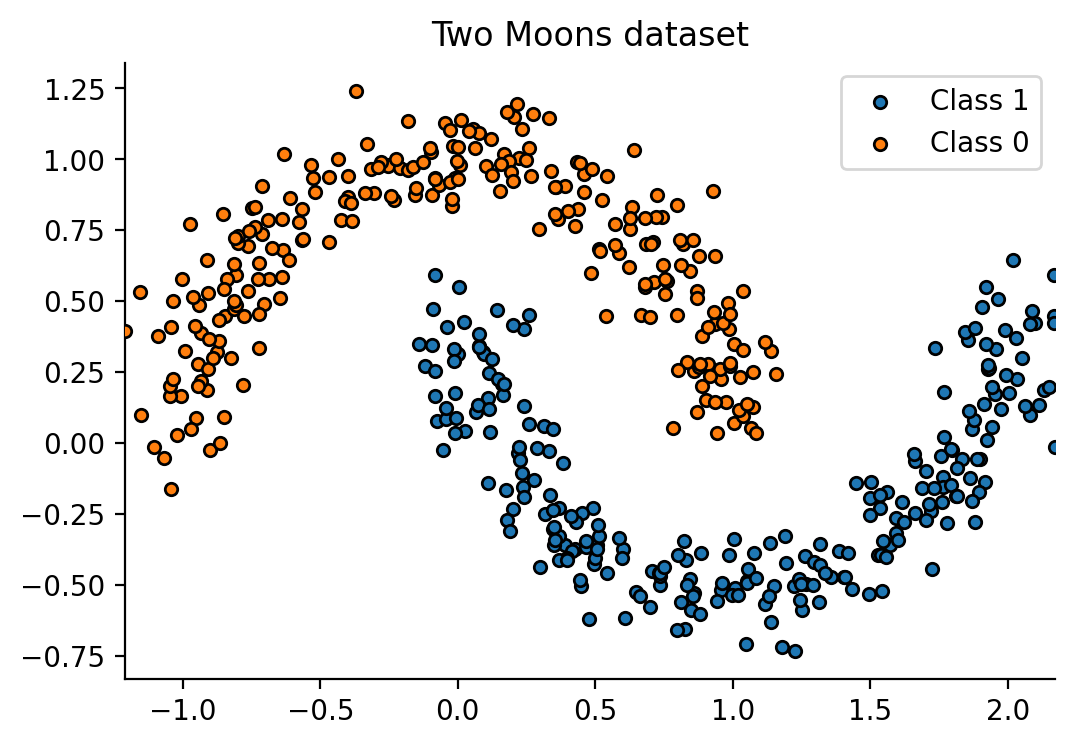

In [3]:


np.random.seed(42)
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
X = jnp.array(X, dtype=jnp.float32, device=jax.devices("cpu")[0])
y = jnp.array(y, dtype=jnp.float32, device=jax.devices("cpu")[0])


def plot_data(X, y, ax):
    X = np.array(X)
    y = np.array(y)
    mask = y == 1
    config = dict(edgecolor="black", linewidth=1, zorder=10, s=20)
    ax.scatter(*X[mask].T, label="Class 1", facecolor="tab:blue", **config)
    ax.scatter(*X[~mask].T, label="Class 0", facecolor="tab:orange", **config)


def get_grid(xlim=(-2, 3), ylim=(-1.5, 2), N=100):
    x_grid = np.linspace(*xlim, N)
    y_grid = np.linspace(*ylim, N)
    xx, yy = np.meshgrid(x_grid, y_grid)
    X_plot = np.vstack((xx.flatten(), yy.flatten())).T
    return xx, yy, X_plot


fig, ax = plt.subplots(figsize=[6, 4])
plot_data(X, y, ax)
ax.set_title("Two Moons dataset")
ax.legend()
plt.show()

---
# Part 2: Model Definition with Flax + NumPyro

We define a 2-layer MLP using Flax, then use NumPyro to make it Bayesian.

In [4]:


class MLP(nn.Module):
    """2-hidden-layer MLP for binary classification."""

    hidden_dim: int = 32
    output_dim: int = 1

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(self.hidden_dim, use_bias=True, name="layer1")(x)
        x = nn.relu(x)

        x = nn.Dense(self.hidden_dim, use_bias=True, name="layer2")(x)
        x = nn.relu(x)

        x = nn.Dense(self.output_dim, use_bias=True, name="layer3")(x)

        return x.squeeze(-1)

In [5]:
def bnn_model(X, y=None, hidden_dim=32):
    """
    Bayesian neural network model using NumPyro + Flax.
    """
    N, D = X.shape
    flax_nn = MLP(hidden_dim=hidden_dim, output_dim=1)

    nn_module = random_flax_module(
        "nn",
        flax_nn,
        prior=dist.Normal(0, 1),
        input_shape=(1, D),
    )
    logits = nn_module(X)
    probs = jax.nn.sigmoid(logits)
    numpyro.deterministic("probs", probs)

    with numpyro.plate("data", N):
        numpyro.sample("obs", dist.Bernoulli(probs=probs), obs=y)


# Test that the model runs
print("Testing model...")
test_model = MLP(hidden_dim=32, output_dim=1)
with jax.default_device(jax.devices("cpu")[0]):
    test_params = test_model.init(jax.random.key(0), jnp.ones((1, 2)))
print(f"Number of parameters: {sum(p.size for p in jax.tree.leaves(test_params))}")

Testing model...
Number of parameters: 1185


**Understanding the Model Architecture**

The MLP has two hidden layers with ReLU activations:
- **Layer 1**: 2 inputs → 32 outputs
- **Layer 2**: 32 → 32
- **Layer 3**: 32 → 1

The `bnn_model` function wraps the Flax MLP in a NumPyro model:
- `random_flax_module`: Creates a stochastic neural network where weights are sampled from the prior
- `numpyro.plate("data", N)`: Vectorizes the likelihood over N data points (observations are independent given weights)
- `dist.Bernoulli(probs=probs)`: Likelihood for binary classification

**Questions:**
1. Why do we use `dist.Normal(0, 1)` as the prior? What does this imply about our assumptions on the weights?
2. How many parameters does the network have? Break this down by layer.
3. What does `jax.nn.sigmoid` do? Why do we need it?

1. We use `dist.Normal(0, 1)` as the prior because it is a common choice for weight priors in Bayesian neural networks. This implies that we assume the weights are centered around zero with a standard deviation of one, which encourages smaller weights and can help prevent overfitting. The normal distribution is also mathematically convenient for inference.
2. The number of parameters in the network can be calculated as follows:
- Layer 1: (2 inputs * 32 outputs) + 32 biases = 96 parameters
- Layer 2: (32 inputs * 32 outputs) + 32 biases = 1056 parameters
- Layer 3: (32 inputs * 1 output) + 1 bias = 33 parameters
Total parameters = 96 + 1056 + 33 = 1185 parameters.
3. `jax.nn.sigmoid` is an activation function that maps any real-valued input to the (0, 1) range. We need it because we are modeling a binary classification problem, and the output of the network represents the probability of belonging to the positive class. The sigmoid function ensures that the output can be interpreted as a probability.

---
# Part 3: Inference Functions

We define helper functions to run different inference methods.
Read carefully to understand how variational inference and MCMC are implemented in NumPyro.


In [6]:
def run_inference(
    method, model, X, y, rng_key=0, num_steps=10000, hidden_dim=32, **kwargs
):
    """
    Unified interface for running different inference methods.

    Args:
        method: One of 'map', 'vi_diagonal', 'vi_full', 'mcmc'
        model: NumPyro probabilistic model
        X: Input data (N x D)
        y: Target labels (N,)
        rng_key: Random key for reproducibility
        num_steps: Number of optimization steps (VI) or warmup steps (MCMC)
        hidden_dim: Hidden dimension for the neural network

    Returns:
        Dictionary containing:
        - 'method': 'vi' or 'mcmc'
        - For VI: 'guide', 'params', 'losses', 'vi_method'
        - For MCMC: 'samples'
    """
    if isinstance(rng_key, int):
        rng_key = jax.random.key(rng_key)

    if method.startswith("vi_") or method == "map":
        return _run_vi(method, model, X, y, rng_key, num_steps, hidden_dim, **kwargs)
    elif method == "mcmc":
        return _run_mcmc(
            model,
            X,
            y,
            rng_key,
            num_warmup=num_steps,
            num_samples=200,
            hidden_dim=hidden_dim,
        )
    else:
        raise ValueError(f"Unknown method: {method}")


def _run_vi(vi_method, model, X, y, rng_key, num_steps, hidden_dim, lr=1e-3, **kwargs):
    """
    Run Stochastic Variational Inference with different guide types.

    The guide defines the variational family q(w; theta):
    - AutoDiagonalNormal: Mean-field approximation (independent Gaussian per weight)
    - AutoMultivariateNormal: Full covariance Gaussian (captures weight correlations)
    - AutoDelta: Point estimate (MAP estimation, no uncertainty)

    Args:
        vi_method: One of 'vi_diagonal', 'vi_full', 'map'
        model: The probabilistic model p(y|X,w)p(w)
        X, y: Training data
        rng_key: Random key
        num_steps: Optimization iterations
        hidden_dim: Network hidden dimension
        lr: Learning rate for Adam optimizer

    Returns:
        Dictionary with VI results and trained parameters
    """
    # Map method name to NumPyro guide class
    guide_map = {
        "vi_diagonal": AutoDiagonalNormal,  # Mean-field: ~2D parameters per weight
        "vi_full": AutoMultivariateNormal,  # Full covariance: O(D^2) parameters
        "map": AutoDelta,  # Point estimate: no uncertainty
    }

    # Initialize the variational guide (approximating distribution q(w))
    guide = guide_map[vi_method](model)

    # Set up SVI: maximize ELBO = E_q[log p(D|w)] - KL(q||p)
    optimizer = numpyro.optim.Adam(lr)
    svi = SVI(model, guide, optimizer, Trace_ELBO(num_particles=1))

    print(f"Training with {vi_method.upper()}...")
    svi_result = svi.run(
        rng_key,
        num_steps=num_steps,
        X=X,
        y=y,
        hidden_dim=hidden_dim,
        progress_bar=True,
    )

    return {
        "method": "vi",
        "vi_method": vi_method,
        "guide": guide,
        "params": svi_result.params,  # Variational parameters (means, stds)
        "losses": svi_result.losses,  # ELBO trajectory for monitoring
    }


def _run_mcmc(
    model, X, y, rng_key, num_warmup=1000, num_samples=200, hidden_dim=32, **kwargs
):
    """
    Run Markov Chain Monte Carlo sampling using the No-U-Turn Sampler (NUTS).

    NUTS is a Hamiltonian Monte Carlo sampler that:
    1. Uses gradient information for efficient exploration
    2. Automatically determines trajectory length (no manual tuning)
    3. Samples from the exact posterior (given enough samples/warmup)

    Args:
        model: The probabilistic model
        X, y: Training data
        rng_key: Random key
        num_warmup: Number of warmup/burn-in iterations (step size tuning + burn-in)
        num_samples: Number of posterior samples to keep (before thinning)
        hidden_dim: Network hidden dimension

    Returns:
        Dictionary with posterior samples
    """
    # NUTS kernel: uses gradient-based proposals via Hamiltonian dynamics
    kernel = NUTS(model, max_tree_depth=7)  # max_tree_depth limits leapfrog steps

    mcmc = MCMC(
        kernel,
        num_warmup=num_warmup,  # Burn-in + step size adaptation
        num_samples=num_samples * 10,  # Total samples before thinning
        progress_bar=True,
        thinning=10,  # Keep every 10th sample (reduces autocorrelation)
    )

    print("Running MCMC with NUTS...")
    mcmc.run(rng_key, X=X, y=y, hidden_dim=hidden_dim)

    return {
        "method": "mcmc",
        "samples": mcmc.get_samples(),  # Dict of {parameter_name: array of samples}
        "losses": None,  # No loss trajectory for MCMC
    }

In [7]:



def make_predictions(model, X_test, result, n_samples=200, rng_key=1, hidden_dim=32):
    """
    Generate predictions using posterior samples.

    This function:
    1. Draws weight samples from the posterior (VI guide or MCMC)
    2. Runs forward pass with each weight sample
    3. Collects predictions to compute mean and variance

    Args:
        model: NumPyro model (used for Predictive inference)
        X_test: Test inputs (N x D)
        result: Output from run_inference containing posterior info
        n_samples: Number of samples to draw (for VI; MCMC uses stored samples)
        rng_key: Random key
        hidden_dim: Network hidden dimension

    Returns:
        probs: All predicted probabilities (n_samples x N), for uncertainty estimation
        mean_probs: Mean predicted probability per input (N,), for point prediction
    """
    if isinstance(rng_key, int):
        rng_key = jax.random.key(rng_key)

    # Step 1: Get posterior weight samples
    # For VI: sample from the learned variational distribution q(w)
    # For MCMC: use the pre-computed chain samples
    if result["method"] == "vi":
        posterior_samples = result["guide"].sample_posterior(
            rng_key,
            result["params"],
            sample_shape=(n_samples,),
            X=X_test,
            hidden_dim=hidden_dim,
        )
    elif result["method"] == "mcmc":
        posterior_samples = result["samples"]
    else:
        raise ValueError(f"Unknown method: {result['method']}")

    # Step 2: Create Predictive object that runs the model with posterior weights
    # This draws n_samples forward passes, each with different weights
    predictive = Predictive(
        model,
        posterior_samples=posterior_samples,
        return_sites=["probs"],  # Only extract probabilities, not logits
    )

    # Step 3: Run all samples through the model
    predictions = predictive(rng_key, X=X_test, hidden_dim=hidden_dim)

    # Step 4: Reshape and compute statistics
    # predictions["probs"] has shape (n_samples, N), transpose to (N, n_samples)
    probs = predictions["probs"].T

    # Mean probability across samples (Bayesian model averaging)
    mean_probs = jnp.mean(probs, axis=1)

    return probs, mean_probs

**Deep Dive: Inference Methods**

### Variational Inference (VI)
VI approximates the intractable posterior $p(\mathbf{w} | \mathcal{D})$ with a simpler distribution $q(\mathbf{w}; \nu)$.
We optimize $\nu$ to minimize the KL divergence $KL(q(\mathbf{w}; \nu) || p(\mathbf{w} | \mathcal{D}))$.

This is equivalent to maximizing the **ELBO** (Evidence Lower Bound):
$$\mathcal{L}(\nu) = \mathbb{E}_{q(\mathbf{w}; \nu)}[\log p(\mathcal{D} | \mathbf{w})] - KL(q(\mathbf{w}; \nu) || p(\mathbf{w}))$$

The first term is the expected log-likelihood (reconstruction), the second is the prior regularization.

### Guides in NumPyro
NumPyro provides "guides" which are parametric families for the variational distribution:
- `AutoDiagonalNormal`: Mean-field approximation $q(\mathbf{w}) = \prod_d \mathcal{N}(\mu_d, \sigma_d^2)$
- `AutoMultivariateNormal`: Full covariance $q(\mathbf{w}) = \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$
- `AutoDelta`: Point estimate (no uncertainty, just maximum a posteriori)

### MCMC with NUTS
NUTS (No-U-Turn Sampler) draws samples from the exact posterior using Hamiltonian dynamics.
- Warmup: Adaptive step size tuning, burn-in period
- Thinning: Keep every k-th sample to reduce autocorrelation
- Trade-off: More accurate but much slower than VI

### Predictions
Uses `numpyro.infer.Predictive` to:
1. Sample weights from the posterior
2. Run forward pass for each sample
3. Collect predictions to compute whatever we want

**Questions about inference methods:**
1. What is the difference between `DiagonalNormal` and `MultivariateNormal`? How does this affect the number of parameters and the expressiveness of the variational distribution?
2. What does the `AutoDelta` correspond to conceptually?

1. The `DiagonalNormal` guide assumes that the variational distribution factorizes over dimensions, meaning that it models each weight independently with its own mean and variance. This results in a simpler model with fewer parameters (2 parameters per weight: mean and variance). In contrast, the `MultivariateNormal` guide models the full covariance between weights, allowing for dependencies between them. This is more expressive but also requires significantly more parameters (mean vector and covariance matrix).
2. The `AutoDelta` guide corresponds to a point estimate of the weights, which is equivalent to maximum a posteriori (MAP) estimation. It does not model uncertainty and simply finds the single set of weights that maximizes the posterior distribution.

### 1. MAP Estimation

In [ ]:
result_map = run_inference(
    method="map",
    model=bnn_model,
    X=X,
    y=y,
    rng_key=0,
    num_steps=10000,
    hidden_dim=32,
)

Training with MAP...


100%|██████████| 10000/10000 [00:01<00:00, 5403.13it/s, init loss: 1493.8733, avg. loss [9501-10000]: 1118.5624]


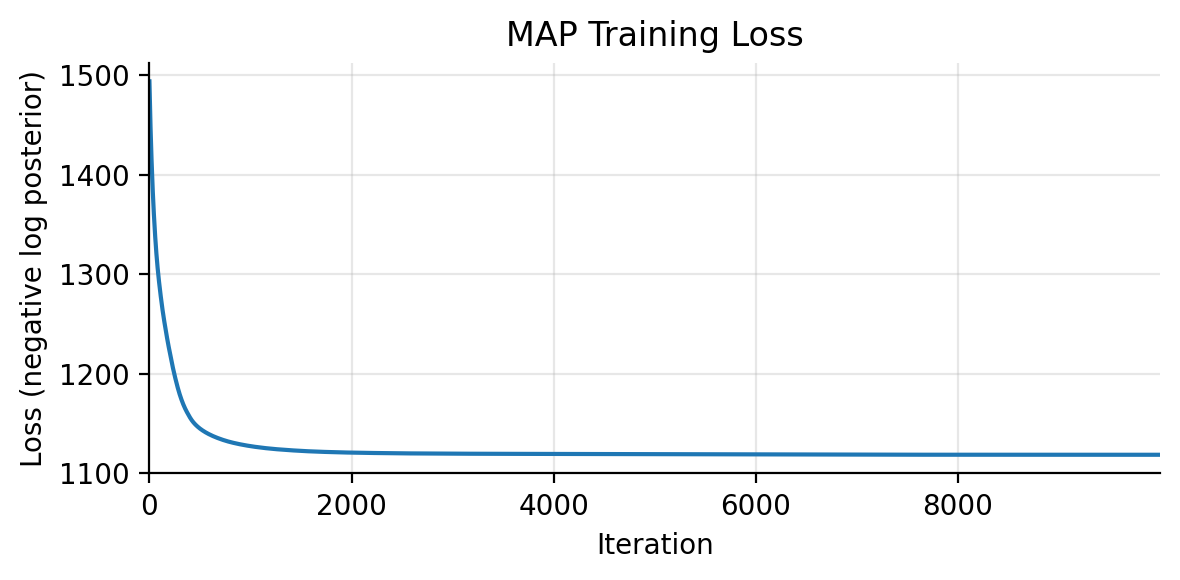

In [ ]:
# Plot training loss
if result_map["losses"] is not None:
    fig, ax = plt.subplots(figsize=[6, 3])
    ax.plot(result_map["losses"])
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss (negative log posterior)")
    ax.set_title("MAP Training Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Understanding the Loss Curve**

The loss shown is the negative ELBO. With `AutoDelta` guide, this simplifies to:
$$-\log p(\mathbf{y} | \mathbf{X}, \mathbf{w}_{MAP}) - \log p(\mathbf{w}_{MAP})$$

i.e., negative log posterior (log-likelihood + log prior).


**Questions after running MAP:**
1. Does the loss converge? Approximately how many iterations does it take?
2. What is MAP optimizing? What does "MAP" stand for? (Maximum A Posteriori)
3. Why does MAP give a point estimate rather than a distribution?

1. The converge is exponential, and it typically takes around 1000 iterations to converge.
2. MAP stands for Maximum A Posteriori. It optimizes the posterior distribution to find the single set of weights that maximizes the posterior probability given the data and the prior.
3. MAP gives a point estimate because it finds the single set of weights that maximizes the posterior distribution, rather than modeling the entire distribution over weights. It does not capture uncertainty and only provides the most likely weights given the data and prior.  

### 2. VI with Diagonal Covariance

In [ ]:
result_vi_diag = run_inference(
    method="vi_diagonal",
    model=bnn_model,
    X=X,
    y=y,
    rng_key=0,
    num_steps=10000,
    hidden_dim=32,
)

Training with VI_DIAGONAL...


100%|██████████| 10000/10000 [00:03<00:00, 2909.37it/s, init loss: 5415.6748, avg. loss [9501-10000]: 390.5563]


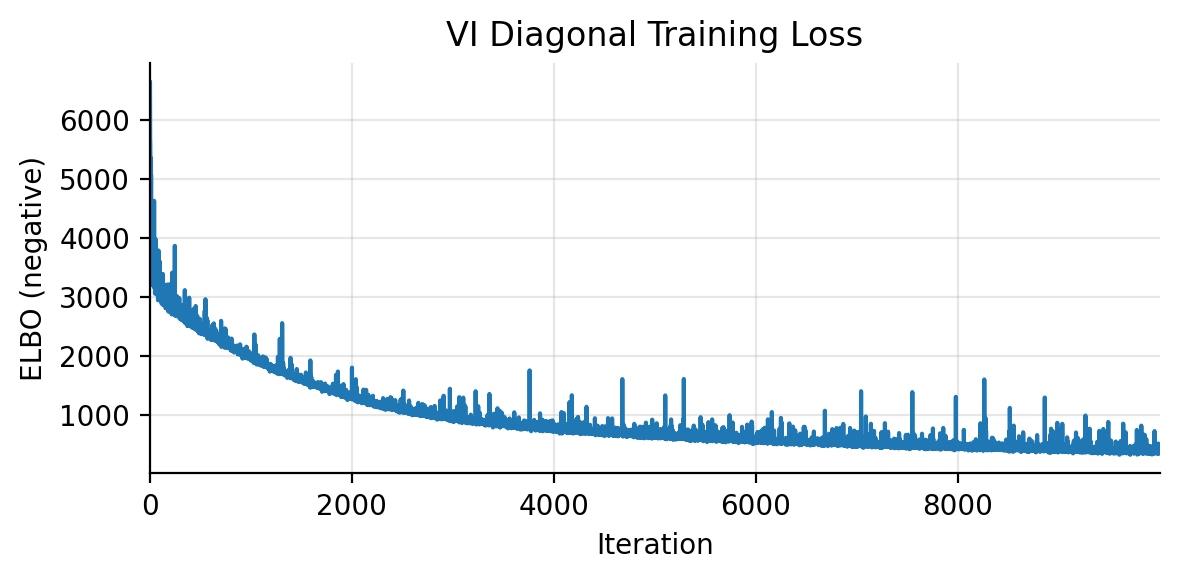

In [ ]:
# Plot training loss
if result_vi_diag["losses"] is not None:
    fig, ax = plt.subplots(figsize=[6, 3])
    ax.plot(result_vi_diag["losses"])
    ax.set_xlabel("Iteration")
    ax.set_ylabel("ELBO (negative)")
    ax.set_title("VI Diagonal Training Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Why the Different Curves?**

The ELBO curve shows the same quantity being optimized (negative log posterior) but:
- **MAP**: Optimizes only the mean, no uncertainty
- **VI**: Optimizes both mean AND variance


**Questions after running VI Diagonal:**
1. How does the ELBO curve differ from the MAP loss curve?
2. What does "diagonal" mean in this context?
3. Why is the curve more noisy than before?

1. The ElBO curve is more noisy than the MAP loss curve because it involves sampling from the variational distribution to estimate the expected log-likelihood, which introduces variance in the gradient estimates. In contrast, MAP optimization is deterministic and does not involve sampling, resulting in a smoother loss curve.
2. "Diagonal" in this context means that the variational distribution assumes that the weights are independent and only models the mean and variance for each weight separately, without modeling any covariance between weights.
3. The curve is more noisy than before because the ELBO is estimated using Monte Carlo sampling from the variational distribution, which introduces variance in the estimates. In contrast, the MAP loss is deterministic and does not involve sampling, resulting in a smoother curve.

### 3. VI with Full Covariance

In [ ]:
result_vi_full = run_inference(
    method="vi_full",
    model=bnn_model,
    X=X,
    y=y,
    rng_key=0,
    num_steps=20000,
    hidden_dim=32,
)

Training with VI_FULL...


100%|██████████| 20000/20000 [02:48<00:00, 118.37it/s, init loss: 5415.6748, avg. loss [19001-20000]: 516.5706]


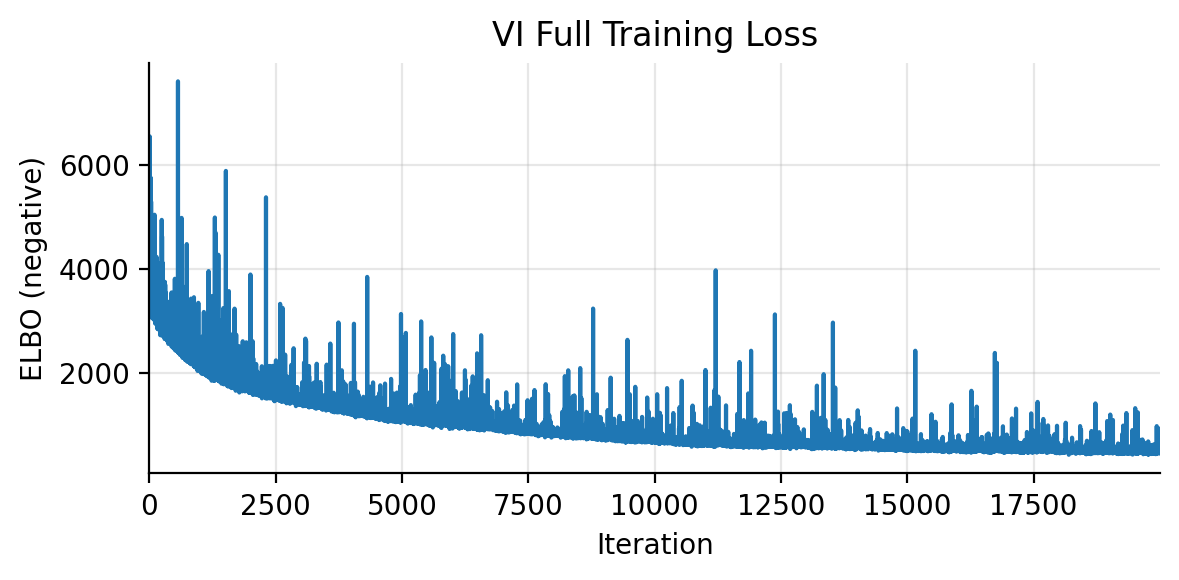

In [ ]:
# Plot training loss
if result_vi_full["losses"] is not None:
    fig, ax = plt.subplots(figsize=[6, 3])
    ax.plot(result_vi_full["losses"])
    ax.set_xlabel("Iteration")
    ax.set_ylabel("ELBO (negative)")
    ax.set_title("VI Full Training Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Why Full Covariance is Computationally Expensive**

Full covariance requires learning a complete covariance matrix:
- Number of parameters: $D + D(D-1)/2 \approx D^2/2$ (where D = number of weights)
- For 1185 weights: ~702,000 parameters (vs 1185 for diagonal)
- Per-step computation is $O(D^2)$ instead of $O(D)$


**Questions after running VI Full:**
1. Compare training time with VI Diagonal. How much slower is full covariance?
2. What is the computational cost difference between diagonal and full covariance?
3. Why full covariance has $D+D(D-1)/2$ parameters? Where dose this formula come from?

1. The training time for VI with full covariance is significantly slower than VI with diagonal covariance due to the increased number of parameters and the computational complexity of handling the covariance matrix. My computer running on CPU used about 2 minutes and 45 seconds for full covariance, compared to about 4 seconds for diagonal covariance.
2. The computational cost difference between diagonal and full covariance is significant. Diagonal covariance has a cost of $O(D)$ for both parameters and computation, while full covariance has a cost of $O(D^2)$ due to the need to compute and store the covariance matrix, which includes all pairwise covariances between weights.
3. The formula $D + D(D-1)/2$ comes from the number of parameters in a multivariate normal distribution. For a D-dimensional multivariate normal, we have:
- D parameters for the mean vector $\boldsymbol{\mu}$
- $D(D-1)/2$ parameters for the covariance matrix $\boldsymbol{\Sigma}$ (since it is symmetric, we only need to store the upper triangular part)
Thus, the total number of parameters is $D$ (mean) + $D(D-1)/2$ (covariance) = $D + D(D-1)/2$. 

### 4. MCMC with NUTS

In [ ]:
result_mcmc = run_inference(
    method="mcmc",
    model=bnn_model,
    X=X,
    y=y,
    rng_key=0,
    num_steps=1000,
    hidden_dim=32,
)

Running MCMC with NUTS...


sample: 100%|██████████| 3000/3000 [00:33<00:00, 90.90it/s, 127 steps of size 1.28e-02. acc. prob=0.90]


In [ ]:
# Setup grid for predictions
xx, yy, X_grid = get_grid((-2, 3), (-1.5, 2), N=80)

**MCMC Parameters Explained**

- `num_warmup=1000`: Number of iterations to tune step size and burn in
- `num_samples=2000`: Actual samples kept (200 samples × 10 thinning)
- `thinning=10`: Keep every 10th sample to reduce autocorrelation


**Questions after running MCMC:**
1. How long does MCMC take compared to VI? Why?
2. What is the "warmup" phase doing?
3. Is MCMC sampling from the true posterior or an approximation?

1. MCMC takes longer time than IV with about 30 secound compared to 4 seconds for VI with diagonal covariance. This is because MCMC is an exact inference method that samples from the true posterior distribution, which requires many iterations and evaluations of the model. In contrast, VI is an optimization-based method that approximates the posterior with a simpler distribution, which is much faster to compute.
2. The "warmup" phase in MCMC is used to tune the sampler's parameters (like step size) and to allow the Markov chain to reach a stationary distribution before collecting samples for inference. The samples collected during warmup are typically discarded as they may not represent the true posterior distribution.
3. MCMC is sampling from the true posterior distribution, given enough iterations and proper convergence. Unlike VI, which approximates the posterior with a parametric family, MCMC methods like NUTS are designed to draw samples from the exact posterior distribution, making them more accurate but also more computationally expensive.

### Generate Predictions

In [ ]:
# MAP predictions
probs_map, mean_probs_map = make_predictions(
    model=bnn_model,
    X_test=X_grid,
    result=result_map,
    n_samples=200,
    rng_key=1,
    hidden_dim=32,
)

# VI diagonal predictions
probs_vi_diag, mean_probs_vi_diag = make_predictions(
    model=bnn_model,
    X_test=X_grid,
    result=result_vi_diag,
    n_samples=200,
    rng_key=1,
    hidden_dim=32,
)

# VI full predictions
probs_vi_full, mean_probs_vi_full = make_predictions(
    model=bnn_model,
    X_test=X_grid,
    result=result_vi_full,
    n_samples=200,
    rng_key=1,
    hidden_dim=32,
)

# MCMC predictions
probs_mcmc, mean_probs_mcmc = make_predictions(
    model=bnn_model,
    X_test=X_grid,
    result=result_mcmc,
    n_samples=200,
    rng_key=1,
    hidden_dim=32,
)

In [ ]:
def plot_decision_boundary(xx, yy, P, ax, title=""):
    P = P.reshape(*xx.shape)
    levels = [0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1]
    ax.contour(xx, yy, P, levels, colors="k", linewidths=1.4, zorder=100)
    ax.contourf(xx, yy, P, levels, cmap="RdBu_r", alpha=0.6)
    ax.set_title(title)

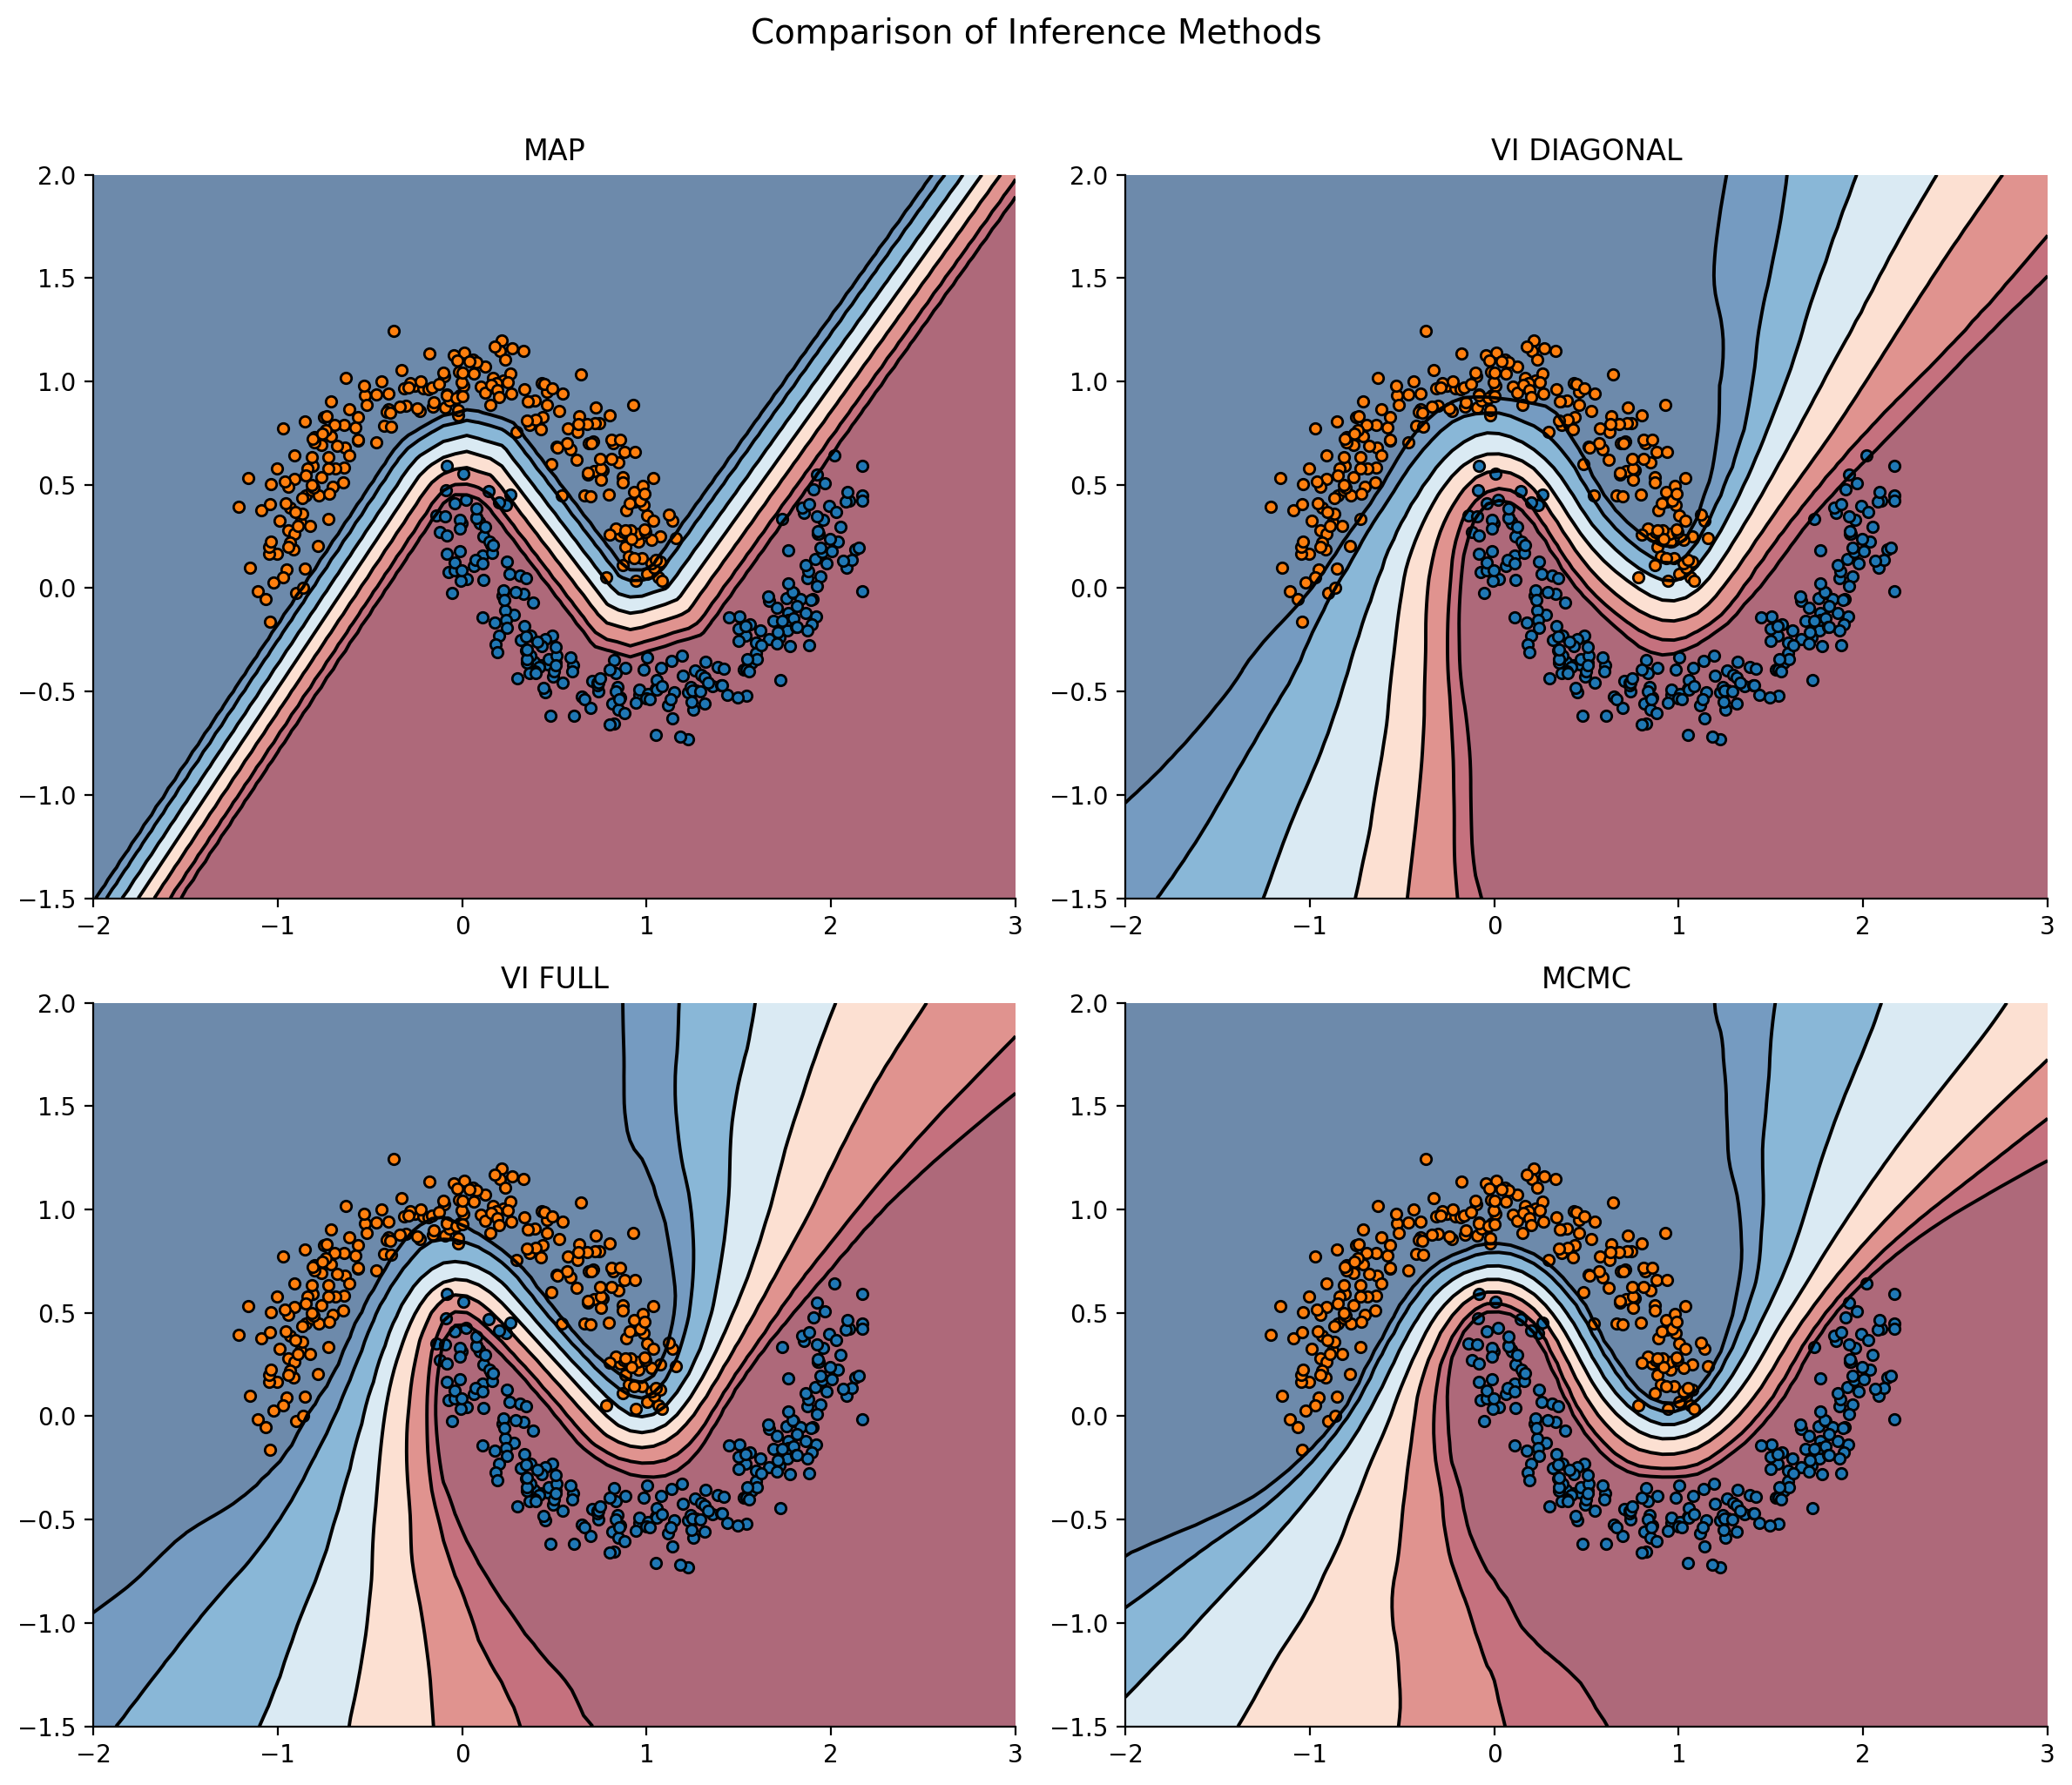

In [ ]:
# Plot all methods in 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=[12, 10])
axes = axes.flatten()

predictions = [
    (mean_probs_map, "MAP"),
    (mean_probs_vi_diag, "VI DIAGONAL"),
    (mean_probs_vi_full, "VI FULL"),
    (mean_probs_mcmc, "MCMC"),
]

for i, (mean_probs, name) in enumerate(predictions):
    plot_decision_boundary(xx, yy, mean_probs, axes[i], name)
    plot_data(X, y, axes[i])

plt.suptitle("Comparison of Inference Methods", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Questions about decision boundaries:**
1. How does the decision boundary differ between MAP and the Bayesian methods?
2. Which regions show the most difference between methods?
3. Is the mean prediction from VI similar to MAP? Why or why not?
4. Compare the smoothness of decision boundaries. What might cause roughness?
5. In which regions do you see the biggest difference between MAP and VI/MCMC means?

1. The decision boundary for MAP is sharper and more confident, while the Bayesian methods (VI and MCMC) show smoother and more uncertain boundaries, especially in regions with less data.
2. The biggest differences appear in the region between the two moons (where classes overlap) and in regions far from any training points (out-of-distribution). Those are where MAP, VI, and MCMC disagree most about the class probability and where epistemic uncertainty is highest.
3. The mean prediction from VI may be similar to MAP in regions with abundant data, but it can differ' in regions with less data or where the model is uncertain, as VI captures uncertainty while MAP does not.
4. The smoothness of decision boundaries can be affected by the amount of data, the complexity of the model, and the inference method. Bayesian methods may produce smoother boundaries due to uncertainty quantification, while MAP may produce sharper boundaries that can overfit to the training data.
5. The biggest difference between MAP and VI/MCMC means is likely in the regions where the classes overlap or where there is less training data, as the Bayesian methods capture uncertainty in these areas while MAP does not. In these regions, the MAP decision boundary may be more confident and sharper, while the VI/MCMC boundaries

---
# Part 4: Uncertainty Decomposition

Bayesian neural networks naturally capture two types of uncertainty:

**Epistemic uncertainty** (model uncertainty) arises from not knowing the model parameters. It is:
- **High** in regions far from training data
- **Low** in regions where we have abundant data
- **Captured** by the variance across posterior samples
- Can be **reduced** by collecting more data

**Aleatoric uncertainty** (data uncertainty) is inherent noise in the data. It is:
- **Independent** of training data location
- **Cannot be reduced** by collecting more data
- **Captured** by the average entropy within each posterior sample

This decomposition is crucial for:
- **Active learning**: Which samples to label next? (high epistemic = learn more)
- **Out-of-distribution detection**: OOD data shows high epistemic uncertainty
- **Risk-sensitive applications**: Know when to defer to humans

## Information-Theoretic Decomposition

The total predictive uncertainty decomposes as:

$$\underbrace{H[y \mid \mathbf{x}]}_{\text{Total}} = \underbrace{I[w; y \mid \mathbf{x}]}_{\text{Epistemic}} + \underbrace{\mathbb{E}_{p(w \mid \mathcal{D})}[H[y \mid \mathbf{x}, w]]}_{\text{Aleatoric}}$$

For **binary classification** with Bernoulli likelihood:
- **Total entropy**: $H_{\text{total}} = -\bar{p} \log \bar{p} - (1-\bar{p}) \log(1-\bar{p})$
- **Aleatoric entropy**: $\frac{1}{S} \sum_{s=1}^S [-p_s \log p_s - (1-p_s) \log(1-p_s)]$
- **Epistemic**: $H_{\text{epistemic}} = H_{\text{total}} - H_{\text{aleatoric}}$

In [15]:
def binary_entropy(p):
    """Binary entropy H(Bernoulli(p)) = -p*log(p) - (1-p)*log(1-p)."""
    p = jnp.clip(p, 1e-6, 1 - 1e-6)
    return -(p * jnp.log(p) + (1 - p) * jnp.log(1 - p))


def total_uncertainty(probs):
    """
    Total uncertainty: entropy of the mean predicted probability.
    """
    # @@ COMPLETE @@
    mean_prob = jnp.mean(probs, axis=1)
    tu = binary_entropy(mean_prob)
    return tu


def aleatoric_uncertainty(probs):
    """
    Aleatoric uncertainty: expected entropy across posterior samples.
    E_q[H[p(y=1|x,w)]] = average entropy for each sample
    """
    # @@ COMPLETE @@
    entropies = binary_entropy(probs)
    au = jnp.mean(entropies, axis=1)
    return au


def epistemic_uncertainty(probs):
    """Epistemic uncertainty = total - aleatoric (mutual information I[y;w|x])."""
    # @@ COMPLETE @@
    eu = total_uncertainty(probs) - aleatoric_uncertainty(probs)
    return eu

[VI Diagonal] Max epistemic: 0.6418
[VI Diagonal] Max aleatoric: 0.2783
[VI Diagonal] Max total: 0.6931


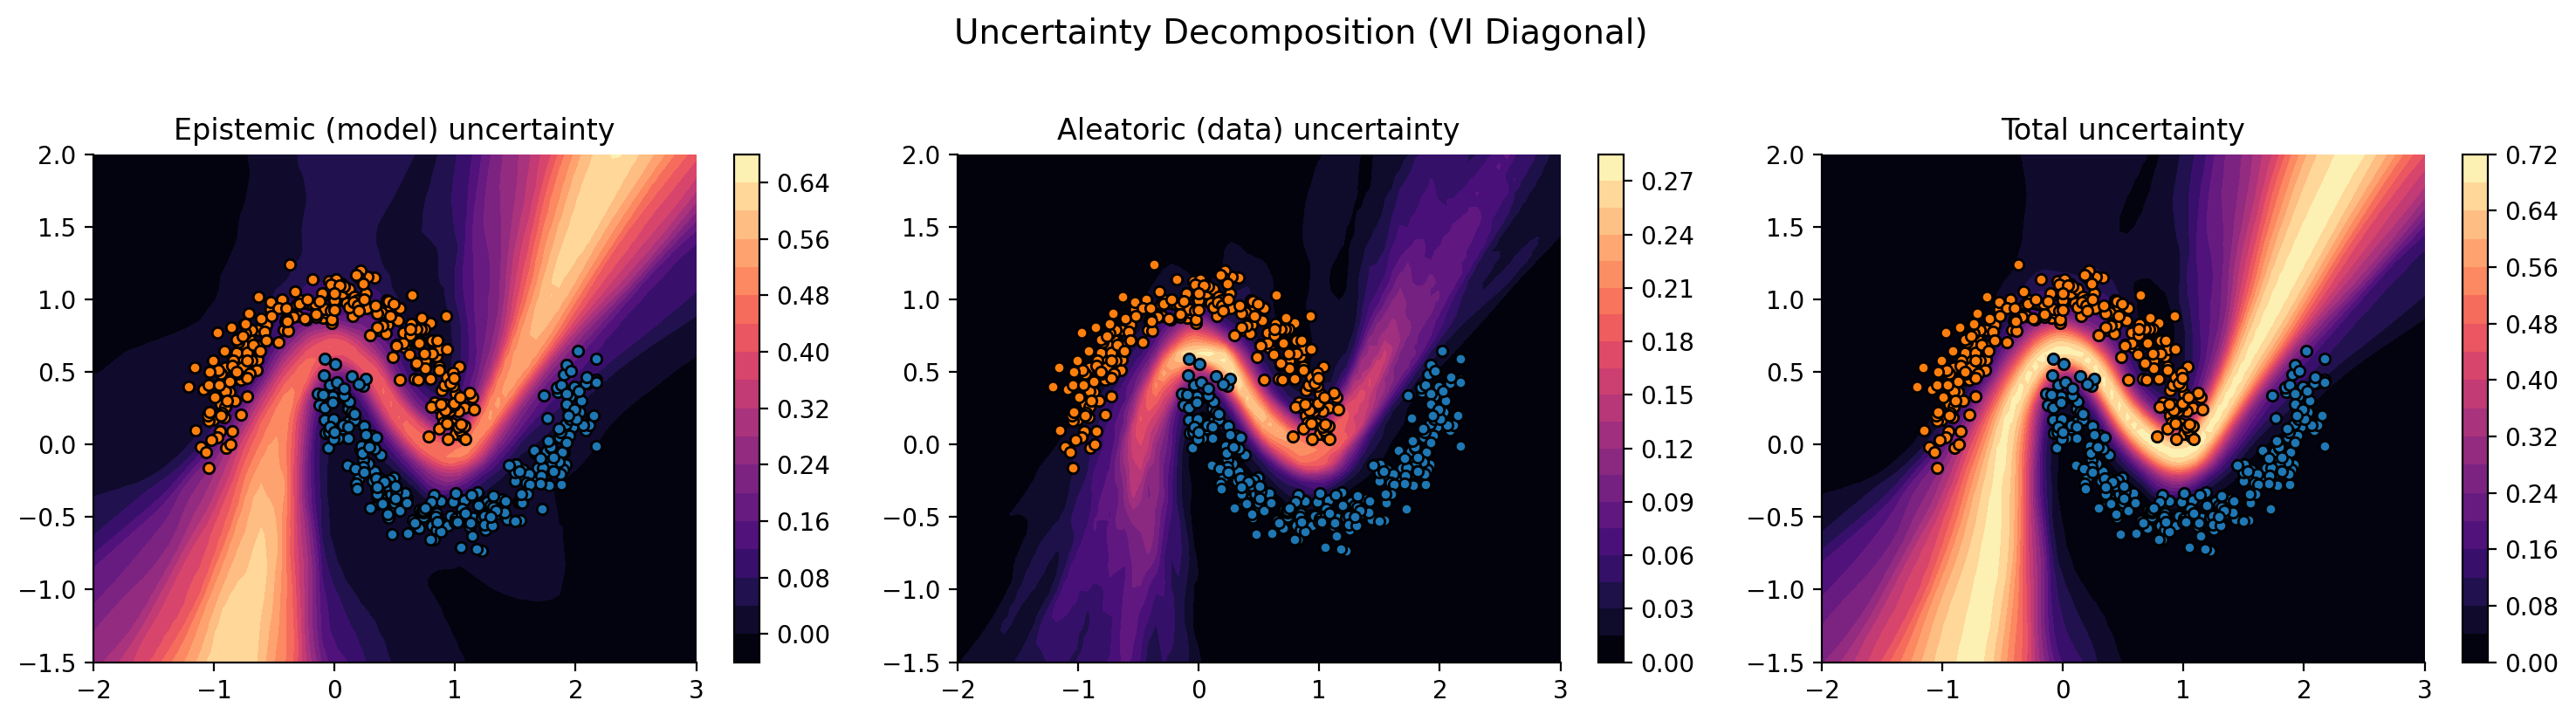

In [ ]:
# Visualize uncertainty decomposition for VI Diagonal
fig, axes = plt.subplots(1, 3, figsize=[15, 4])

total_unc = total_uncertainty(probs_vi_diag).reshape(*xx.shape)
aleatoric_unc = aleatoric_uncertainty(probs_vi_diag).reshape(*xx.shape)
epistemic_unc = epistemic_uncertainty(probs_vi_diag).reshape(*xx.shape)

print(f"[VI Diagonal] Max epistemic: {jnp.max(epistemic_unc):.4f}")
print(f"[VI Diagonal] Max aleatoric: {jnp.max(aleatoric_unc):.4f}")
print(f"[VI Diagonal] Max total: {jnp.max(total_unc):.4f}")

im0 = axes[0].contourf(xx, yy, epistemic_unc, levels=20, cmap="magma")
axes[0].set_title("Epistemic (model) uncertainty")
plot_data(X, y, axes[0])
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(xx, yy, aleatoric_unc, levels=20, cmap="magma")
axes[1].set_title("Aleatoric (data) uncertainty")
plot_data(X, y, axes[1])
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(xx, yy, total_unc, levels=20, cmap="magma")
axes[2].set_title("Total uncertainty")
plot_data(X, y, axes[2])
plt.colorbar(im2, ax=axes[2])

plt.suptitle("Uncertainty Decomposition (VI Diagonal)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Questions about uncertainty decomposition:**
1. Where is the **aleatoric** uncertainty highest? Why is it high there?
2. Where is the **epistemic** uncertainty highest? What does this tell us?
3. Look at the regions far from the training data. Which type of uncertainty dominates there?
4. In the region between the two moons, which type of uncertainty is higher?

1. The uncertainty for aleatoric is highest in the region where the two moons overlap. This is because in this region, the data points from both classes are mixed together, leading to inherent noise in the labels. The model cannot confidently assign a class label to these points, resulting in high aleatoric uncertainty.
2. The epistemic uncertainty is highest in regions far from the training data, such as the corners of the plot. This indicates that the model is uncertain about its predictions in these areas because it has not seen any data there and is unsure about the correct class label.
3. In regions far from the training data, epistemic uncertainty dominates because the model has not seen any examples in those areas and is therefore uncertain about its predictions. Aleatoric uncertainty may be low in these regions since there may not be any inherent noise in the data, but the model's lack of knowledge leads to high epistemic uncertainty.
4. In the region between the two moons, aleatoric uncertainty is higher because the data points from both classes are mixed together, leading to inherent noise in the labels. The model cannot confidently assign a class label to these points, resulting in high aleatoric uncertainty. Epistemic uncertainty may also be present, but the dominant source of uncertainty in this region is aleatoric.

[MCMC] Max epistemic: 0.6244
[MCMC] Max aleatoric: 0.5197
[MCMC] Max total: 0.6931


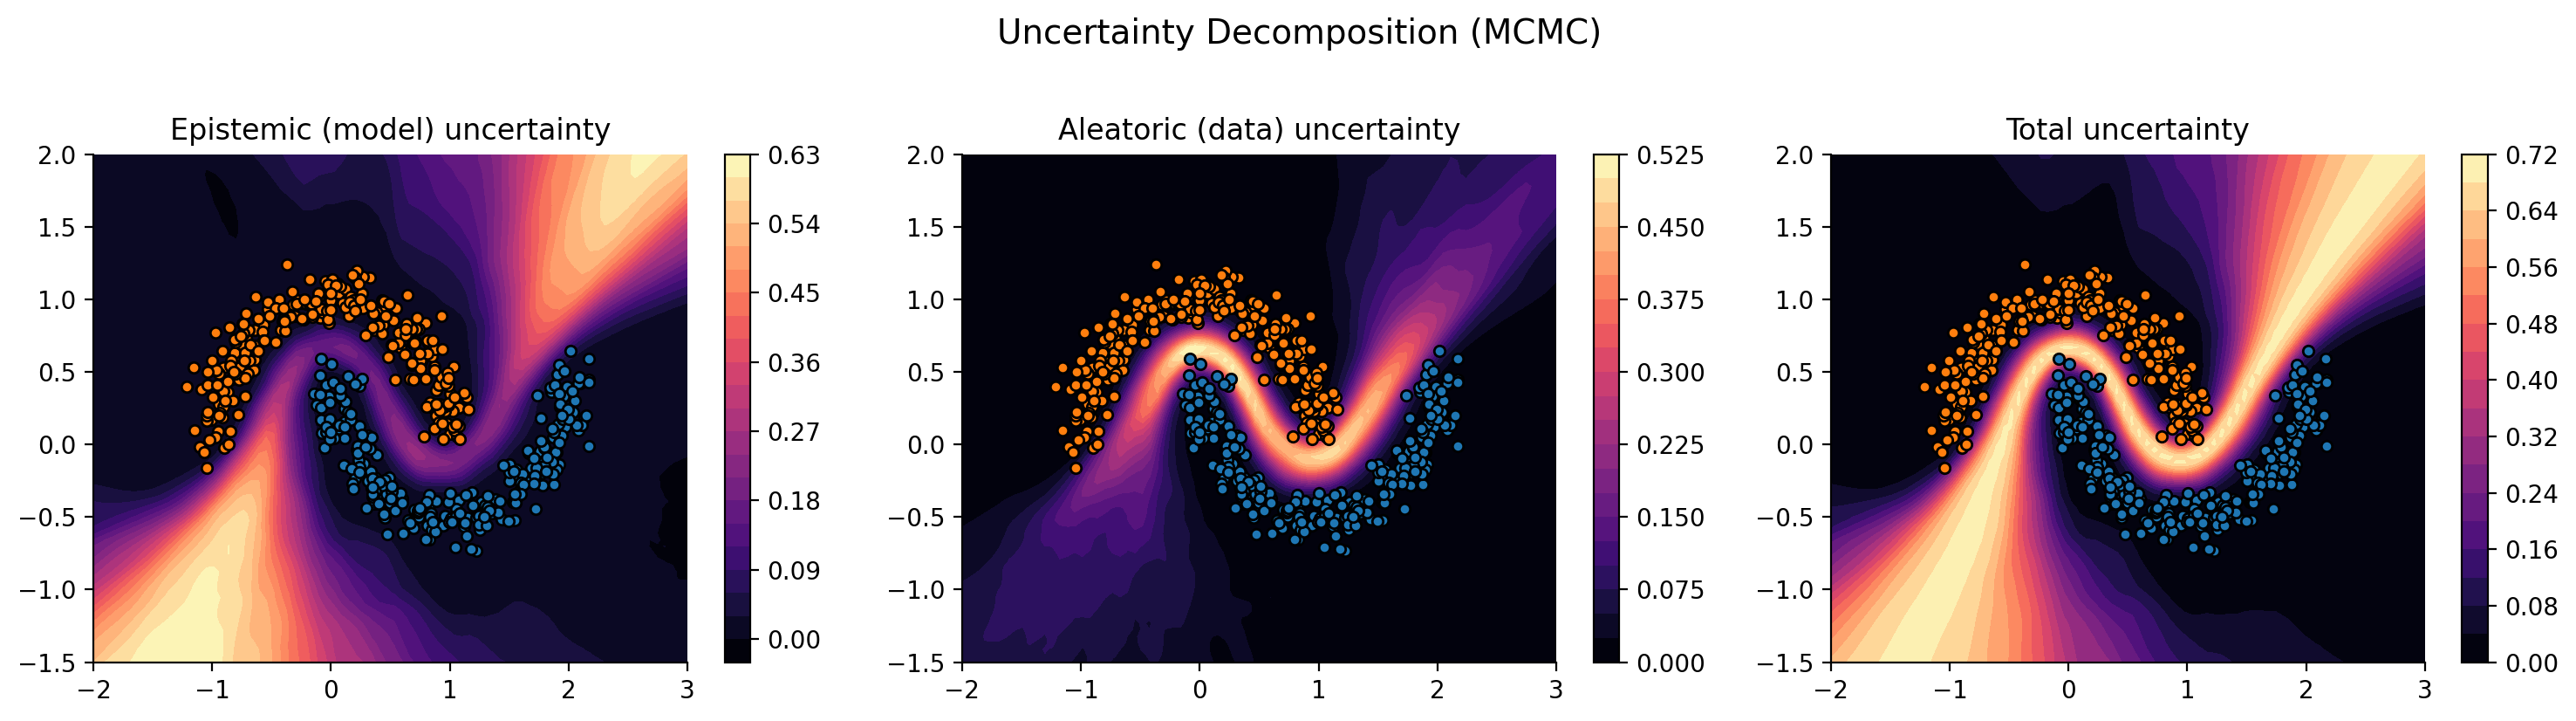

In [ ]:
# Visualize uncertainty decomposition for MCMC
fig, axes = plt.subplots(1, 3, figsize=[15, 4])

total_unc = total_uncertainty(probs_mcmc).reshape(*xx.shape)
aleatoric_unc = aleatoric_uncertainty(probs_mcmc).reshape(*xx.shape)
epistemic_unc = epistemic_uncertainty(probs_mcmc).reshape(*xx.shape)

print(f"[MCMC] Max epistemic: {jnp.max(epistemic_unc):.4f}")
print(f"[MCMC] Max aleatoric: {jnp.max(aleatoric_unc):.4f}")
print(f"[MCMC] Max total: {jnp.max(total_unc):.4f}")

im0 = axes[0].contourf(xx, yy, epistemic_unc, levels=20, cmap="magma")
axes[0].set_title("Epistemic (model) uncertainty")
plot_data(X, y, axes[0])
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(xx, yy, aleatoric_unc, levels=20, cmap="magma")
axes[1].set_title("Aleatoric (data) uncertainty")
plot_data(X, y, axes[1])
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(xx, yy, total_unc, levels=20, cmap="magma")
axes[2].set_title("Total uncertainty")
plot_data(X, y, axes[2])
plt.colorbar(im2, ax=axes[2])

plt.suptitle("Uncertainty Decomposition (MCMC)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Questions comparing VI and MCMC uncertainty:**
1. How do the epistemic uncertainty maps compare between VI and MCMC?
2. Are there regions where one method shows more epistemic uncertainty than the other?
3. What does this suggest about the approximation quality of VI?
4. Which method would you trust more for safety-critical applications?

1. The epistemic uncertainty maps for VI and MCMC are qualitatively similar, showing high uncertainty in regions far from the training data and in the overlap region between the two moons. However, MCMC may show slightly higher epistemic uncertainty in some regions due to its ability to capture the true posterior distribution more accurately than VI.
2. Yes, there are regions where MCMC shows more epistemic uncertainty than VI, particularly in areas where the model is less certain due to limited data. This suggests that VI may underestimate epistemic uncertainty in some regions due to its approximation of the posterior distribution.
3. This suggests that the approximation quality of VI may be limited in certain regions, particularly where the true posterior is complex or multi-modal. VI may fail to capture the full extent of uncertainty in these areas, leading to underestimation of epistemic uncertainty compared to MCMC.
4. For safety-critical applications, I would trust MCMC more due to its ability to capture the true posterior distribution and provide a more accurate representation of uncertainty. While VI is faster, its approximation may lead to underestimation of uncertainty, which can be dangerous in safety-critical scenarios where understanding the full extent of uncertainty is crucial for making informed decisions.

---
# Part 5: MNIST Classification with CNN

Now we scale to a real image classification task using **MNIST**.
We use a small **CNN** for better performance on images.
We'll use **stochastic VI** with minibatches for scalability.

## 5.1 Load and Visualize MNIST Data

MNIST contains 70,000 handwritten digit images (0-9), 28×28 pixels each.
We use a small subset (10000 train, 10000 test) for faster training while
still demonstrating uncertainty quantification on real data.

In [8]:
import jax
metal = next((d for d in jax.devices() if d.platform.lower()=='metal'), None)
print('default_backend', jax.default_backend(), 'metal_device:', metal)

import sys
print("=" * 60)
print("KERNEL DIAGNOSTIC")
print("=" * 60)
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print()

import jax
print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")
print(f"JAX backend: {jax.default_backend()}")
print()

# Check if Metal is in the path
if ".venv-metal" in sys.executable:
    print("✓ CORRECT: Using .venv-metal kernel")
else:
    print("✗ WRONG: NOT using .venv-metal kernel")
    print(f"  Found: {sys.executable}")

default_backend METAL metal_device: METAL:0
KERNEL DIAGNOSTIC
Python executable: /Users/torstein/Desktop/Skole/Studie/8.Semester/ASI/asi-labs/.venv-metal/bin/python
Python version: 3.11.11 (main, Dec  3 2024, 17:20:40) [Clang 16.0.0 (clang-1600.0.26.4)]

JAX version: 0.10.0
JAX devices: [METAL(id=0)]
JAX backend: METAL

✓ CORRECT: Using .venv-metal kernel


In [9]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load MNIST
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_mnist = mnist.data.astype(np.float32) / 255.0  # Normalize to [0, 1]
y_mnist = mnist.target.astype(np.int32)

# Use subset for faster training
n_train = 10000
n_test = 10000
X_train, X_test, y_train, y_test = train_test_split(
    X_mnist,
    y_mnist,
    train_size=n_train,
    test_size=n_test,
    random_state=42,
    stratify=y_mnist,
)

# WORKAROUND: Keep as numpy first, convert to jnp after Metal is confirmed in Part 5
# This avoids Metal initialization issues during array creation
print(f"Training set (numpy): {X_train.shape}")
print(f"Test set (numpy): {X_test.shape}")
print(f"Classes: {np.unique(y_train)}")
print("\nNote: Arrays will be converted to JAX arrays in Part 5 after Metal is configured.")
print(f"X_train dtype: {X_train.dtype}, y_train dtype: {y_train.dtype}")

Training set (numpy): (10000, 784)
Test set (numpy): (10000, 784)
Classes: [0 1 2 3 4 5 6 7 8 9]

Note: Arrays will be converted to JAX arrays in Part 5 after Metal is configured.
X_train dtype: float32, y_train dtype: int32


**Question:** Why do we normalize pixel values to [0, 1]? What would happen if we didn't?

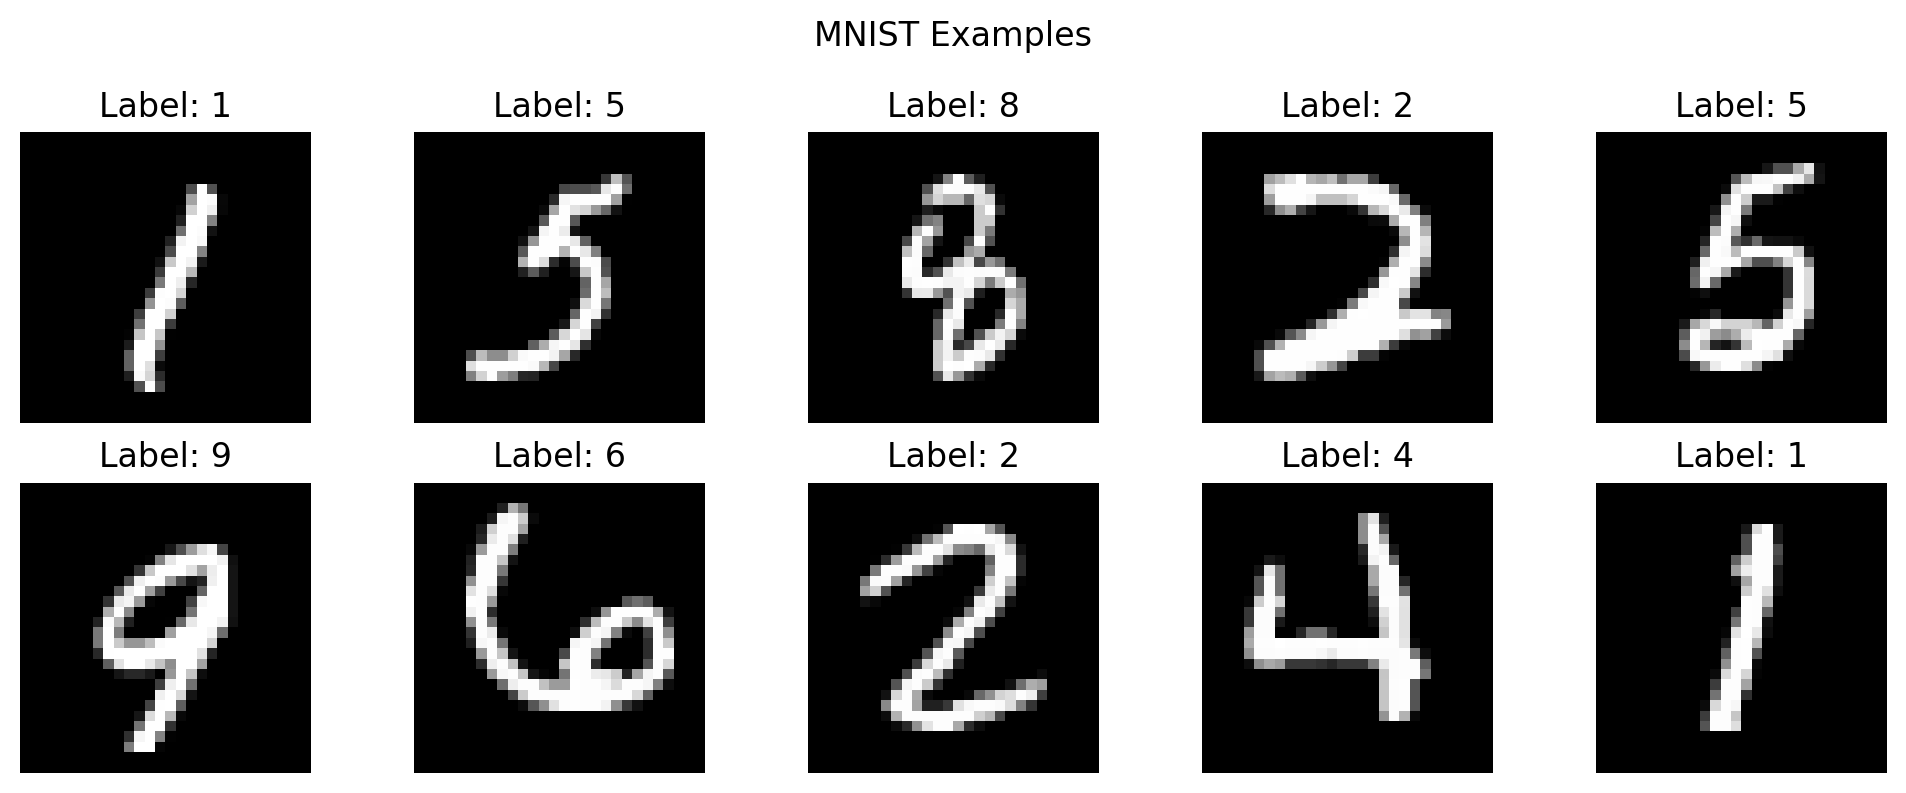

In [10]:
# Visualize some examples
fig, axes = plt.subplots(2, 5, figsize=[10, 4])
for i, ax in enumerate(axes.flat):
    ax.imshow(np.array(X_train[i]).reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {int(y_train[i])}")
    ax.axis("off")
plt.suptitle("MNIST Examples")
plt.tight_layout()
plt.show()

## 5.2 Define CNN Model with Flax

**Why CNN instead of MLP?**
- Convolutional layers exploit spatial structure: a digit is still recognizable
  regardless of where it appears in the 28×28 grid
- 3 convolutional blocks (Conv → ReLU → AvgPool) progressively increase features
- 8 → 16 → 32 channels (doubling each block)
- Final dense layers for classification

In [11]:
class CNN(nn.Module):
    """Simple CNN for MNIST classification."""

    num_classes: int = 10

    @nn.compact
    def __call__(self, x):
        # Reshape to image format (batch, height, width, channels)
        x = x.reshape(-1, 28, 28, 1)

        # Conv block 1: 3x3 conv -> 8 filters
        x = nn.Conv(features=8, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))

        # Conv block 2: 3x3 conv -> 16 filters
        x = nn.Conv(features=16, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))

        # Conv block 3: 3x3 conv -> 32 filters
        x = nn.Conv(features=32, kernel_size=(3, 3), padding="SAME")(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))

        # Flatten and dense
        x = x.reshape(x.shape[0], -1)
        x = nn.Dense(128)(x)
        x = nn.relu(x)
        x = nn.Dense(self.num_classes)(x)

        return x


# Initialize and check model
cnn_model = CNN(num_classes=10)
with jax.default_device(jax.devices("cpu")[0]):
    dummy_input = jnp.ones((1, 784))
    cnn_params = cnn_model.init(jax.random.key(0), dummy_input)
print(f"CNN parameters: {sum(p.size for p in jax.tree.leaves(cnn_params))}")

CNN parameters: 44170


## 5.3 Define Bayesian CNN Model with NumPyro

The Bayesian CNN is identical to the deterministic CNN, but NumPyro will
place Normal(0,1) priors on ALL convolution and dense layer weights.

Key differences from BNN for binary classification:
- 10 classes instead of 2
- Logits (unnormalized) passed to distribution, not probabilities (for numerical stability)
- Cross-entropy loss implicitly computed

In [12]:
def cnn_bnn_model(X, y=None):
    """
    Bayesian CNN model using NumPyro + Flax.
    Uses a Normal(0, 1) prior over all weights.
    """
    N, D = X.shape
    flax_cnn = CNN(num_classes=10)

    nn_module = random_flax_module(
        "cnn",
        flax_cnn,
        prior=dist.Normal(0, 1),
        input_shape=(1, D),
    )

    logits = nn_module(X)
    numpyro.deterministic("logits", logits)

    with numpyro.plate("data", N):
        numpyro.sample("obs", dist.Categorical(logits=logits), obs=y)

**Question:** What is the difference between `dist.Categorical` and `dist.Bernoulli`?
Why do we use it here instead of Bernoulli?

The difference between `dist.Categorical` and `dist.Bernoulli` is that `dist.Categorical` is used for multi-class classification problems where there are more than two classes, while `dist.Bernoulli` is used for binary classification problems where there are only two classes. In this case, since we are working with the MNIST dataset which has 10 classes (digits 0-9), we use `dist.Categorical` to model the likelihood of each class, rather than `dist.Bernoulli` which would only be appropriate for a binary classification task.

## 5.4 Variational Inference for MNIST


In [16]:
import jax

# Metal is available, but this JAX/jax-metal stack currently fails on key/array creation.
# Use CPU for the VI run so the notebook can complete end-to-end.
jax.config.update("jax_default_device", jax.devices("cpu")[0])

from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoDiagonalNormal

guide = AutoDiagonalNormal(cnn_bnn_model)
optimizer = numpyro.optim.Adam(1e-3)
svi = SVI(cnn_bnn_model, guide, optimizer, Trace_ELBO(num_particles=1))

print(f"Training Bayesian CNN with VI on {jax.default_backend()}...")
svi_result = svi.run(
    jax.random.key(0),
    num_steps=10000,
    X=X_train,
    y=y_train,
    progress_bar=True,
)


Training Bayesian CNN with VI on METAL...


100%|██████████| 10000/10000 [9:23:55<00:00,  3.38s/it, init loss: 139130672.0000, avg. loss [9501-10000]: 105430.0469]   


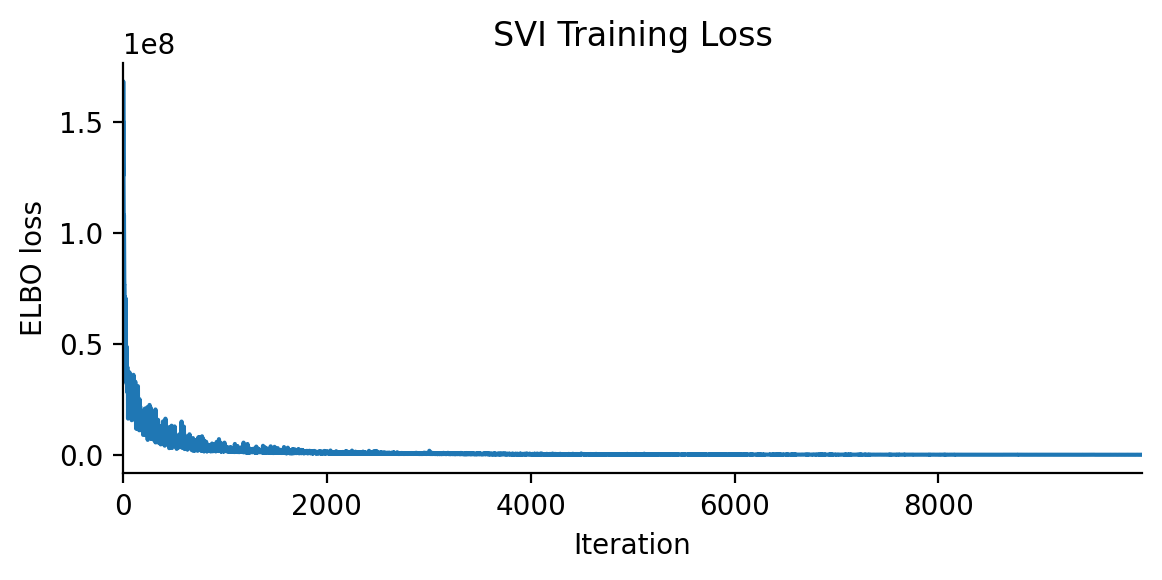

In [17]:
fig, ax = plt.subplots(figsize=[6, 3])
ax.plot(svi_result.losses)
ax.set_xlabel("Iteration")
ax.set_ylabel("ELBO loss")
ax.set_title("SVI Training Loss")
plt.tight_layout()
plt.show()

**Question:** Does the loss converge? How does the final loss compare to early iterations?

The loss does converge very fast over iterations. The final loss is significantly lower than the early iterations, indicating that the model is learning and improving its fit to the data as training progresses.

## 5.5 Making Predictions

In [18]:

# Create predictive object
predictive = Predictive(
    cnn_bnn_model, guide=guide, params=svi_result.params, num_samples=100
)

# Get predictions on test set
print("Generating predictions with 100 posterior samples...")
predictions = predictive(jax.random.key(1), X_test)
mean_pred = jnp.mean(predictions["logits"], axis=0).argmax(axis=-1)
print(f"Prediction shape: {mean_pred.shape}")

# Mean prediction
accuracy = jnp.mean(mean_pred == y_test)
print(f"Test accuracy (mean prediction): {accuracy:.3f}")

Generating predictions with 100 posterior samples...
Prediction shape: (10000,)
Test accuracy (mean prediction): 0.972


## 5.6 Uncertainty Analysis

For multiclass classification, the entropy formulas extend naturally:
- **Total entropy**: $H[\bar{p}] = -\sum_c \bar{p}_c \log \bar{p}_c$ where $\bar{p}$ is mean probability
- **Aleatoric entropy**: Average of per-sample entropies $\frac{1}{S}\sum_s H[p_s]$
- **Epistemic**: $H[\bar{p}] - \bar{H}[p_s] = I[y; w | x]$ (mutual information)

We use `Predictive` with `num_samples=100`:
1. Sample 100 weight configurations from the posterior
2. Run forward pass for each sample → 100 logit vectors per input
3. Average logits across samples
4. Take argmax for final prediction


In [19]:
def categorical_entropy(probs):
    """Multiclass entropy H[Cat(p)] = -sum_c p_c*log(p_c)."""
    probs_safe = jnp.clip(probs, 1e-8, 1 - 1e-8)
    return -jnp.sum(probs_safe * jnp.log(probs_safe), axis=-1)


def multiclass_uncertainty_from_logits(all_logits):
    """
    Compute uncertainty decomposition for multiclass classification.
    all_logits: shape (n_samples, n_points, n_classes)
    """
    all_probs = jax.nn.softmax(all_logits, axis=-1)

    # Total: entropy of mean probability
    mean_probs = jnp.mean(all_probs, axis=0)
    # @@ COMPLETE @@
    total = categorical_entropy(mean_probs)

    # Aleatoric: mean entropy per sample
    # @@ COMPLETE @@
    entropies = categorical_entropy(all_probs)
    aleatoric = jnp.mean(entropies, axis=0)

    # Epistemic = total - aleatoric
    epistemic = total - aleatoric
    return epistemic, aleatoric, total


# Get logits for uncertainty computation
print("Computing uncertainty...")
rng = jax.random.key(1)
all_logits = predictive(rng, X=X_test)["logits"]

all_logits = jnp.stack(all_logits, axis=0)
epistemic, aleatoric, total_unc = multiclass_uncertainty_from_logits(all_logits)

print(f"Mean epistemic: {jnp.mean(epistemic):.4f}")
print(f"Mean aleatoric: {jnp.mean(aleatoric):.4f}")
print(f"Mean total: {jnp.mean(total_unc):.4f}")

Computing uncertainty...
Mean epistemic: 0.0704
Mean aleatoric: 0.0009
Mean total: 0.0713


**Question:** What does high epistemic uncertainty mean for a specific test image?

The high epistemic uncertainty for a specific test image means that the model is uncertain about its prediction for that image due to a lack of knowledge or data in that region of the input space. This could indicate that the model has not seen similar examples during training, and therefore cannot confidently assign a class label to that image. High epistemic uncertainty suggests that the model's predictions for that image may be unreliable and that additional data or information may be needed to improve the model's performance on similar inputs.

## 5.7 Examples with High Epistemic Uncertainty

High epistemic uncertainty images show **model disagreement** - different posterior
samples give different predictions. This indicates the image is unusual or ambiguous.

The $\checkmark$ and $\times$ symbols show whether the prediction is correct,
but the key insight is: high epistemic uncertainty often correlates with difficulty.

These are samples where the model's predictions disagree depending on which posterior sample is used.
This typically happens for ambiguous or unusual inputs.

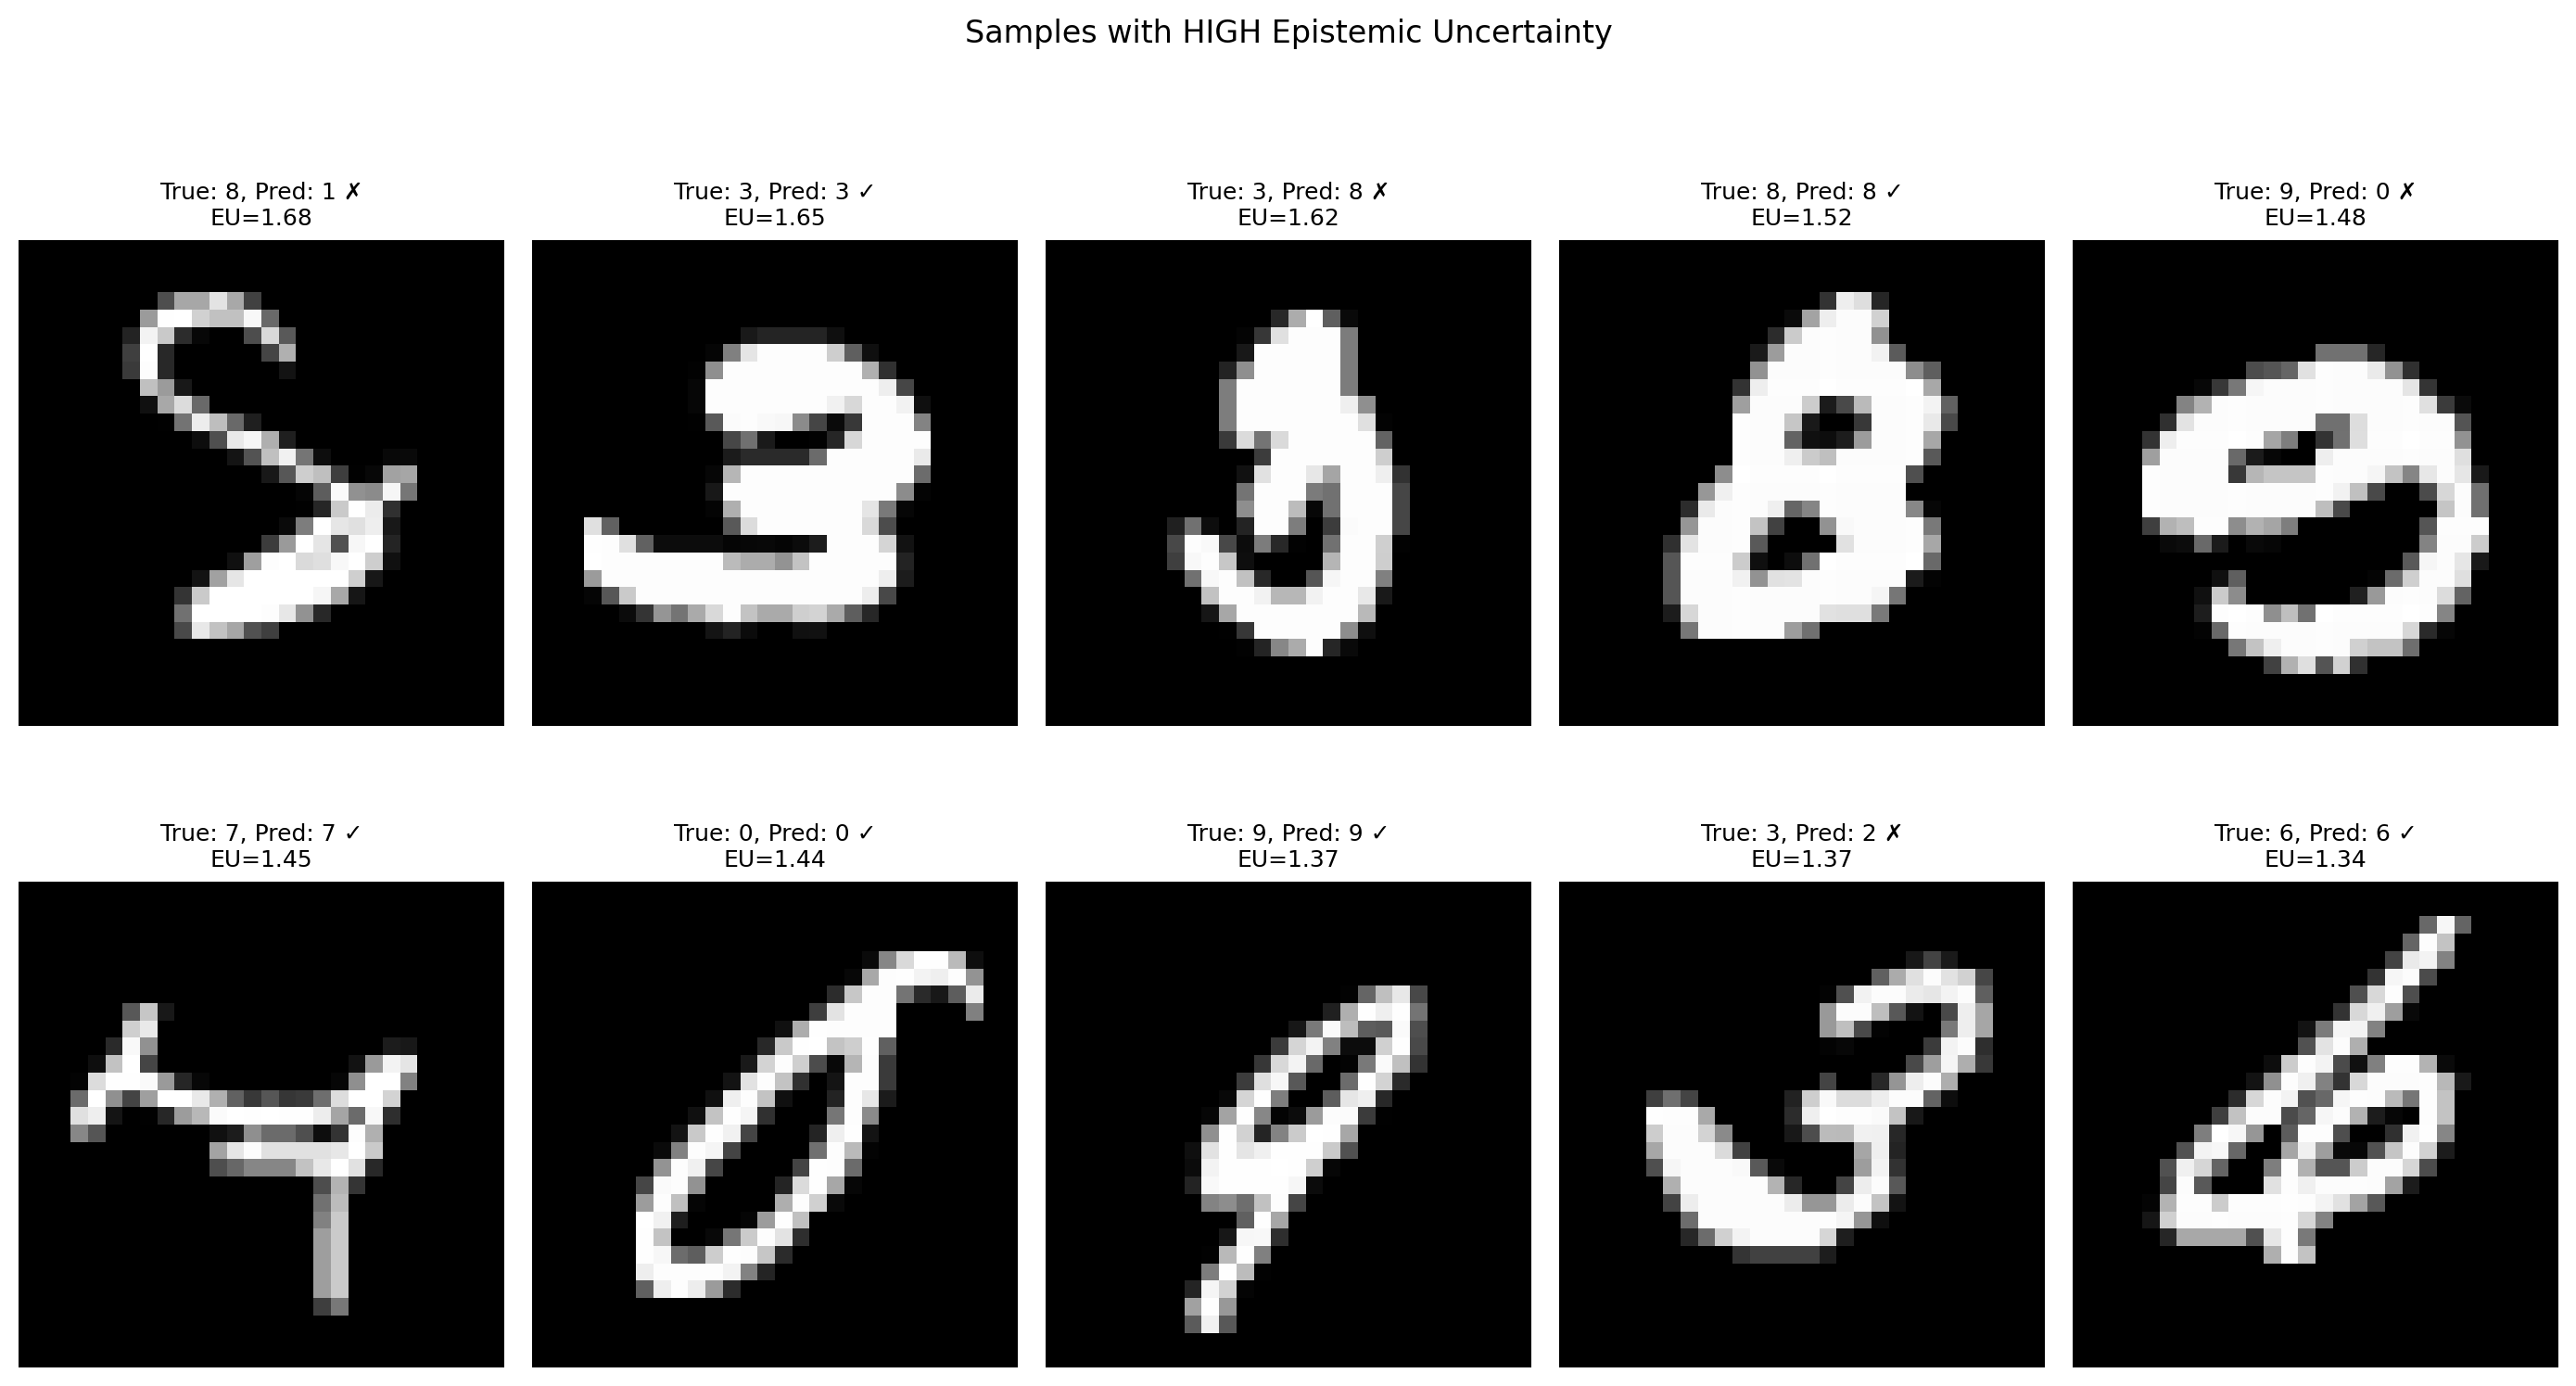

In [20]:
# Sort by epistemic uncertainty (high first)
high_eu_idx = np.argsort(epistemic)[::-1]

fig, axes = plt.subplots(2, 5, figsize=[14, 8])
for i, ax in enumerate(axes.flat):
    idx = high_eu_idx[i]
    ax.imshow(np.array(X_test[idx]).reshape(28, 28), cmap="gray")

    true_label = int(y_test[idx])
    pred_label = int(mean_pred[idx])
    correct = "✓" if true_label == pred_label else "✗"

    ax.set_title(
        f"True: {true_label}, Pred: {pred_label} {correct}\nEU={epistemic[idx]:.2f}",
        fontsize=9,
    )
    ax.axis("off")

plt.suptitle("Samples with HIGH Epistemic Uncertainty", y=1.01)
plt.tight_layout()
plt.show()

**Questions:**
1. Look at the images with highest epistemic uncertainty. Are they difficult to recognize?
2. Is the model correct or incorrect on these examples?
3. What does high epistemic uncertainty tell us about these images?

1. No they ar not difficult to recognize. They are clear and well-formed digits that should be easy for a human to identify.
2. The model is correct on these examples, as indicated by the $\checkmark$ symbols. Despite the high epistemic uncertainty, the model's predictions for these images are accurate.
3. High epistemic uncertainty in these images suggests that the model is uncertain about its predictions for these specific inputs, possibly due to a lack of similar examples in the training data or because these images are outliers in the input space. However, since the model is still able to make correct predictions, it indicates that the model's uncertainty is not necessarily indicative of poor performance, but rather a reflection of the model's recognition of its own limitations in certain regions of the input space.

## 5.8 Comparing Low vs High Uncertainty Examples

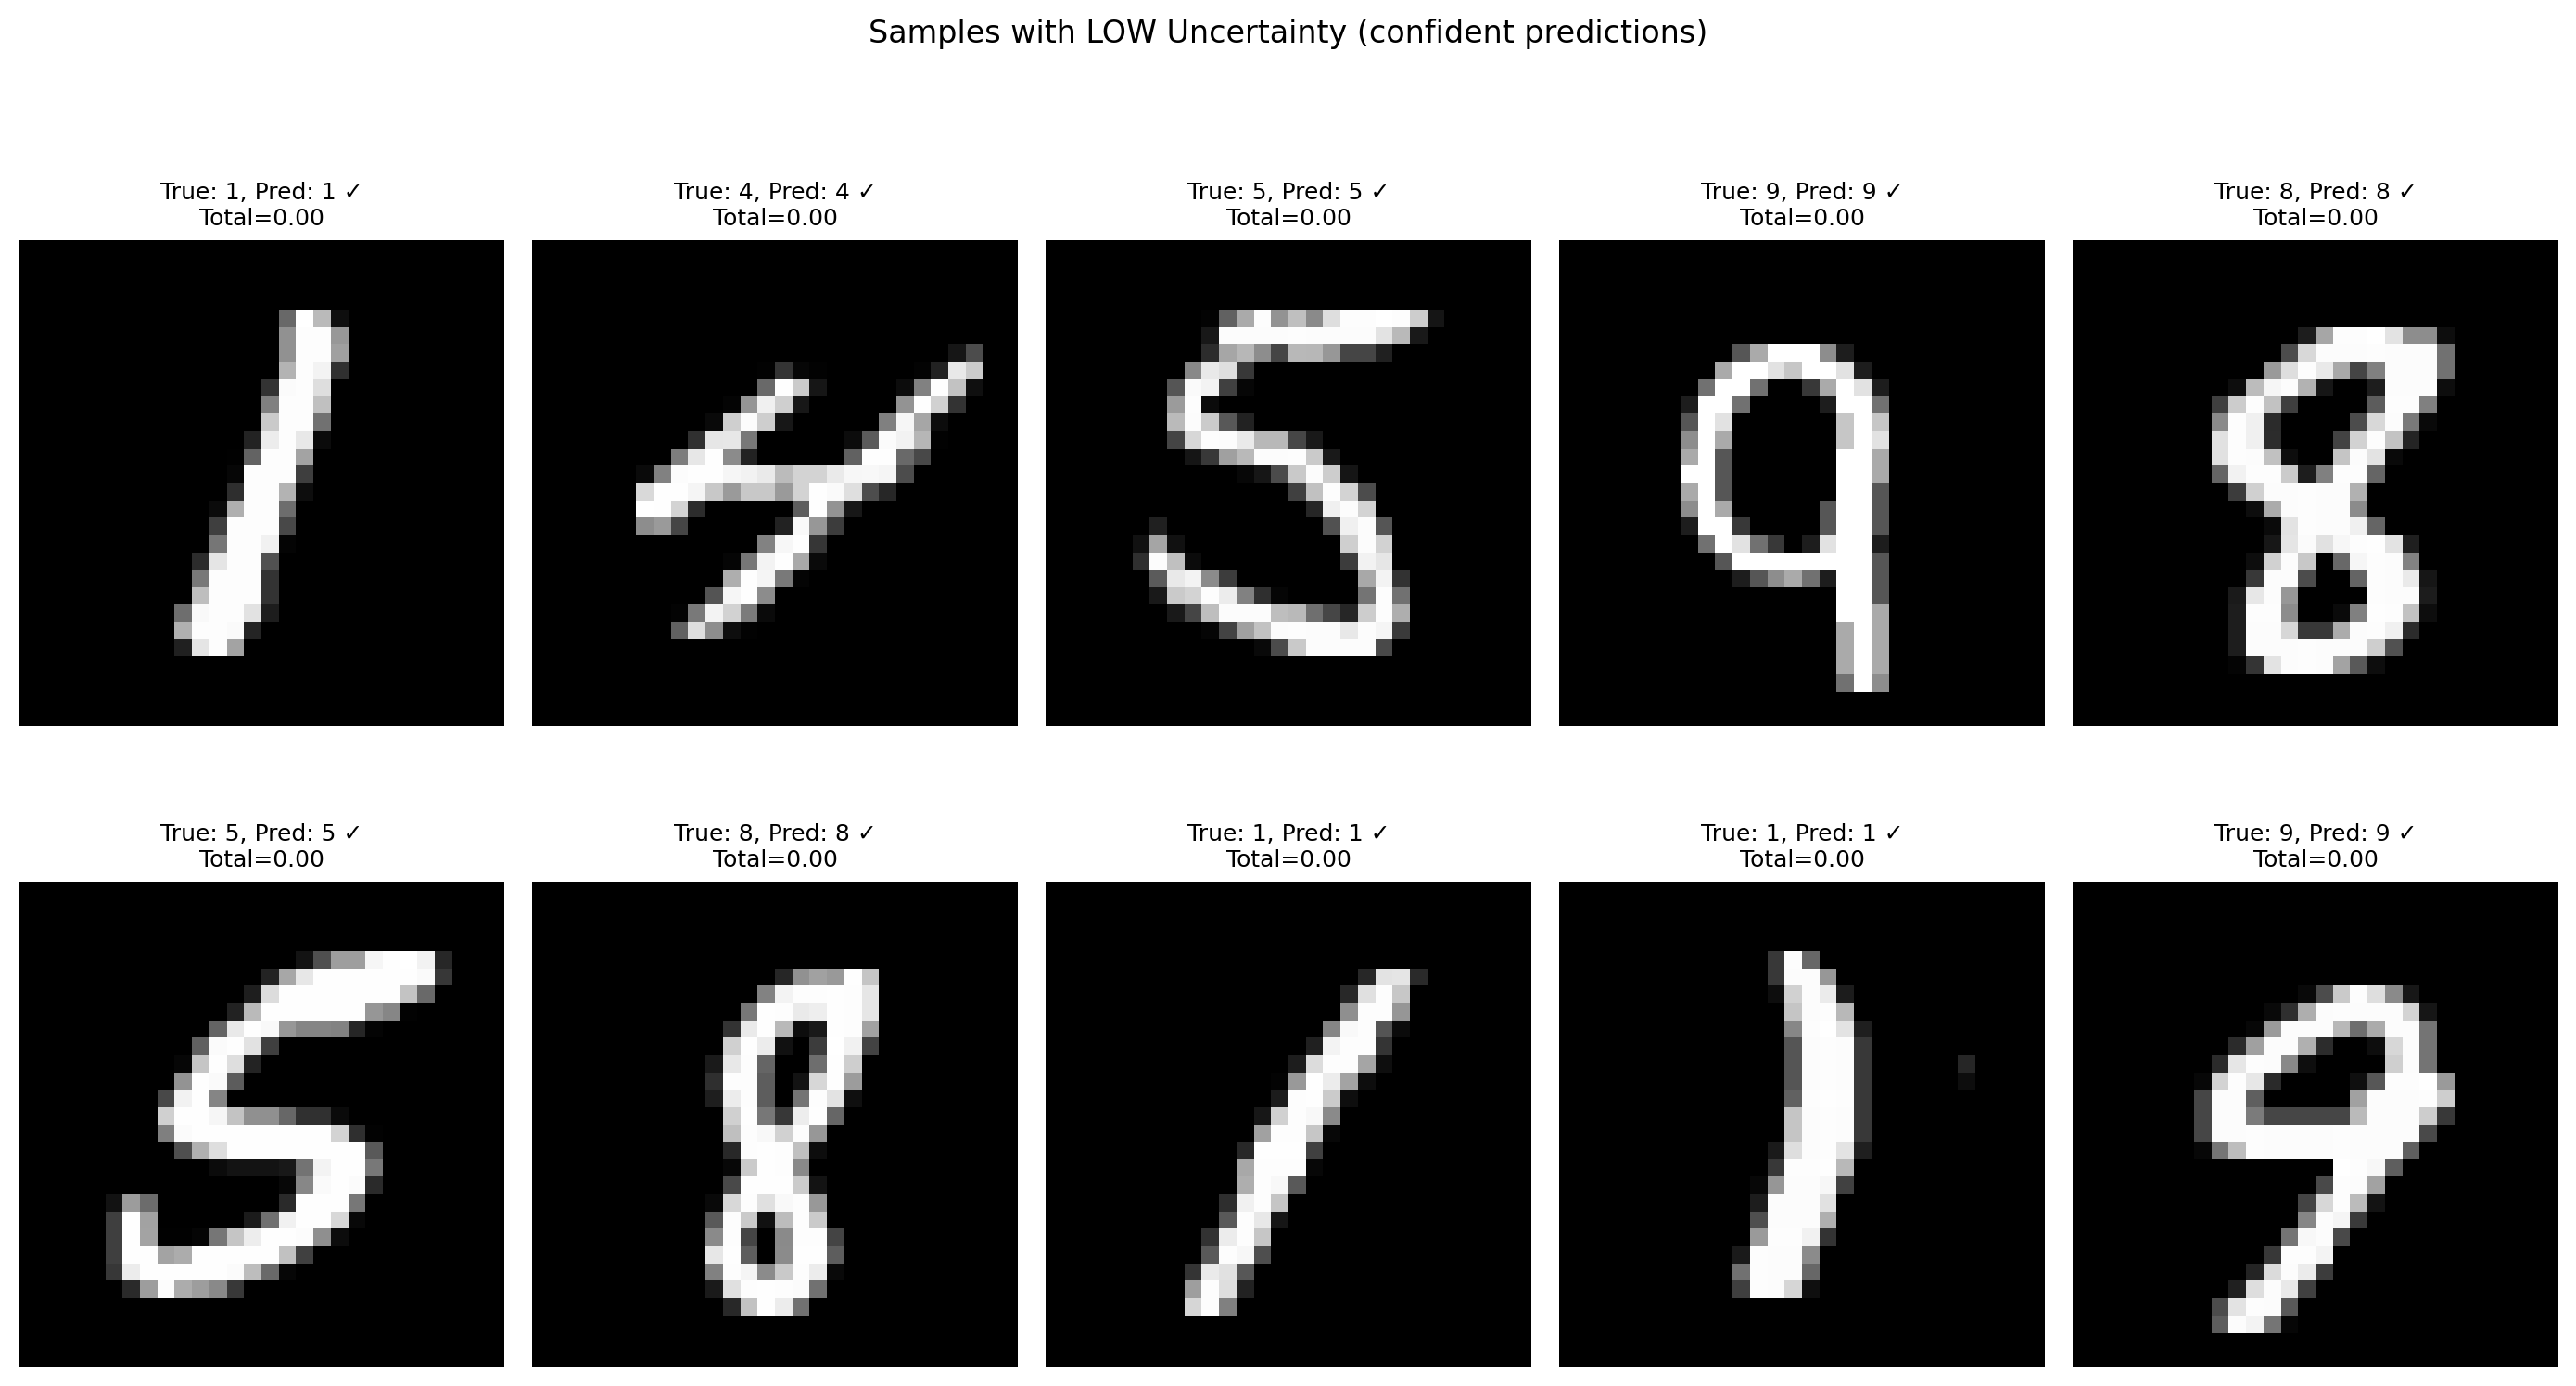

In [21]:
# Low uncertainty examples
low_unc_idx = np.argsort(total_unc)[:10]

fig, axes = plt.subplots(2, 5, figsize=[14, 8])
for i, ax in enumerate(axes.flat):
    idx = low_unc_idx[i]
    ax.imshow(np.array(X_test[idx]).reshape(28, 28), cmap="gray")

    true_label = int(y_test[idx])
    pred_label = int(mean_pred[idx])
    correct = "✓" if true_label == pred_label else "✗"

    ax.set_title(
        f"True: {true_label}, Pred: {pred_label} {correct}\nTotal={total_unc[idx]:.2f}",
        fontsize=9,
    )
    ax.axis("off")

plt.suptitle("Samples with LOW Uncertainty (confident predictions)", y=1.01)
plt.tight_layout()
plt.show()

**Question:** Compare the low-uncertainty images to the high-uncertainty ones.
What patterns do you notice? Are these images easier to classify?

These images are easier to classify. They are clear, well-formed digits that closely resemble the typical examples in the training data. The model is more confident in its predictions for these images, as indicated by the low epistemic uncertainty, which suggests that the model has seen similar examples during training and can confidently assign class labels to these inputs. In contrast, the high-uncertainty images may be more ambiguous or unusual, leading to greater model disagreement and higher epistemic uncertainty.

## 5.9 Out-of-Distribution (OOD) Detection

One key application of Bayesian NNs: detecting when inputs are unlike training data.

We test with **random noise images** - clearly not MNIST digits.

The histogram comparison shows whether uncertainty alone can distinguish
in-distribution from OOD data - crucial for safety-critical AI systems.

OOD data (e.g., random noise) should show higher uncertainty.

In [22]:
# Generate OOD: random noise images
rng_ood = jax.random.key(42)
X_ood = jax.random.uniform(rng_ood, shape=(500, 784), minval=0, maxval=1)

# Get logits for OOD
print("Computing uncertainty on OOD (noise) data...")
all_logits_ood = predictive(jax.random.key(2), X=X_ood)["logits"]

all_logits_ood = jnp.stack(all_logits_ood, axis=0)
epistemic_ood, aleatoric_ood, total_unc_ood = multiclass_uncertainty_from_logits(
    all_logits_ood
)

print("In-distribution (test):")
print(f"  Epistemic: {jnp.mean(epistemic):.4f}, Aleatoric: {jnp.mean(aleatoric):.4f}")
print("OOD (noise):")
print(
    f"  Epistemic: {jnp.mean(epistemic_ood):.4f}, Aleatoric: {jnp.mean(aleatoric_ood):.4f}"
)

Computing uncertainty on OOD (noise) data...
In-distribution (test):
  Epistemic: 0.0704, Aleatoric: 0.0009
OOD (noise):
  Epistemic: 0.7820, Aleatoric: 0.0067


**Question:** Which type of uncertainty is higher for OOD data?
Why does this make sense? (Think: OOD data has no structure for the model to learn)

The OOD data has higher epistemic uncertainty. This makes sense because OOD data does not have the same structure or patterns as the training data, leading to a lack of knowledge about how to classify it. The model is uncertain about its predictions for OOD inputs because it has not seen similar examples during training, resulting in high epistemic uncertainty. In contrast, aleatoric uncertainty may not necessarily be higher for OOD data, as it is related to inherent noise in the data rather than the model's knowledge.

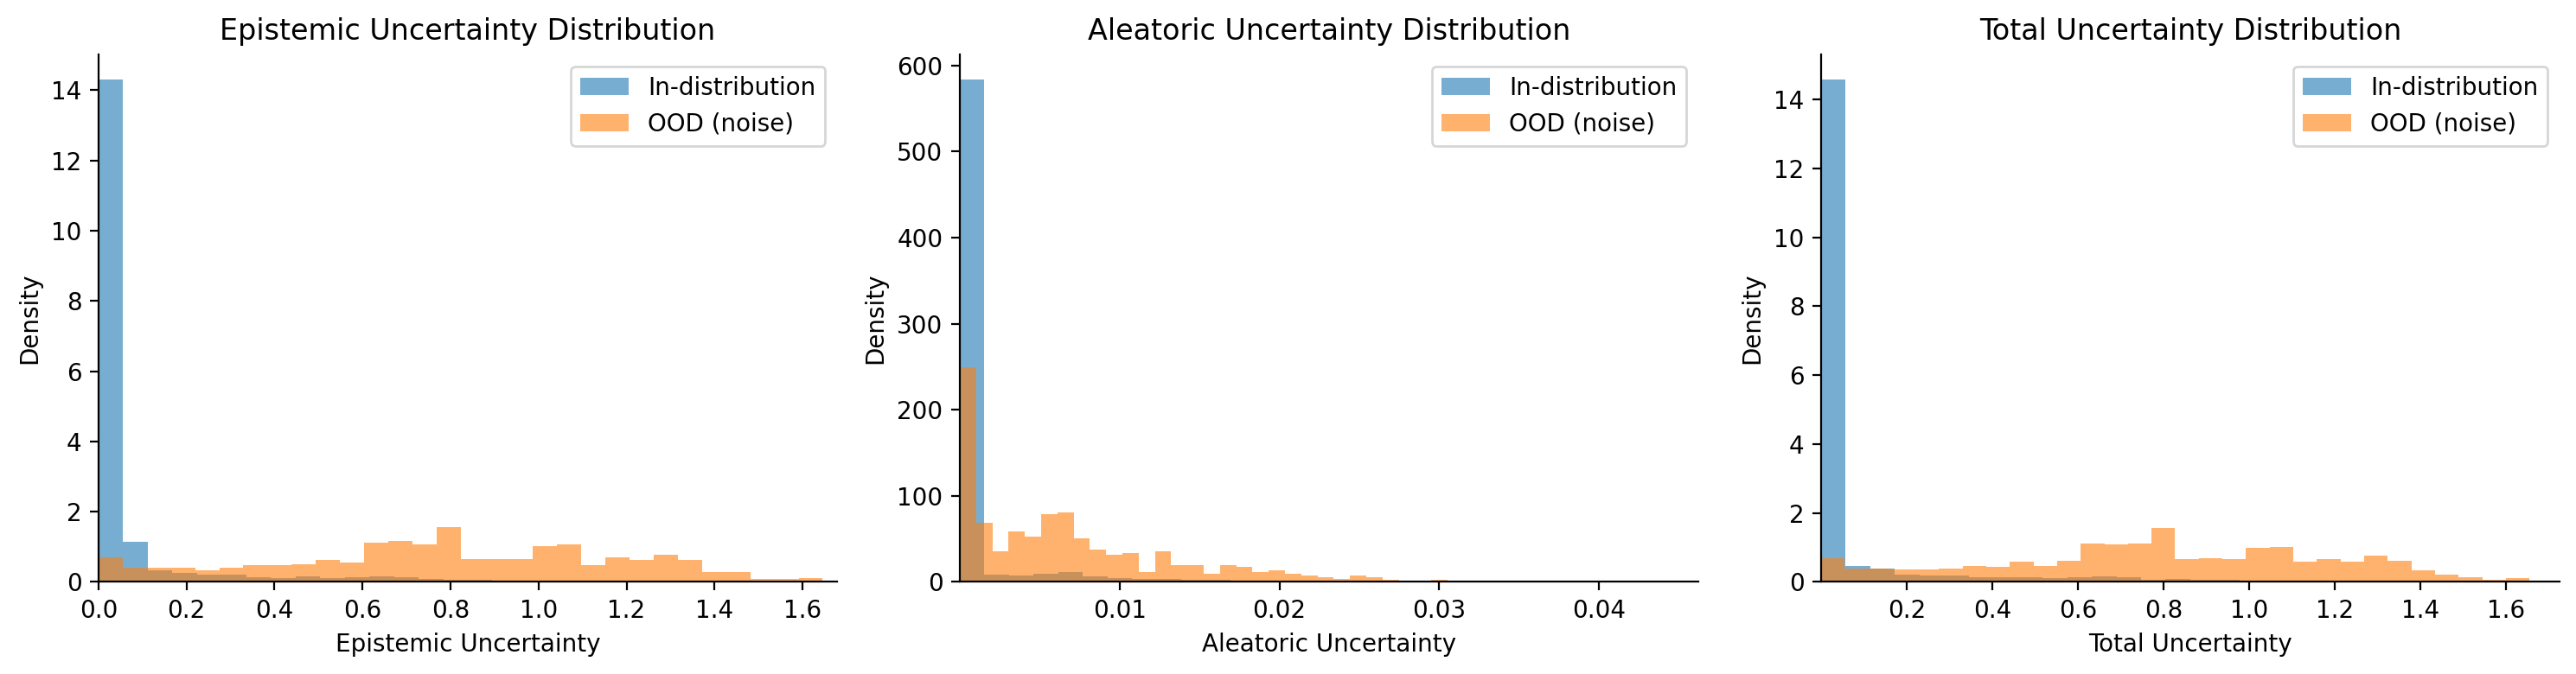

In [23]:
# Compare uncertainty distributions
fig, axes = plt.subplots(1, 3, figsize=[15, 4])

# Epistemic
axes[0].hist(epistemic, bins=30, alpha=0.6, label="In-distribution", density=True)
axes[0].hist(epistemic_ood, bins=30, alpha=0.6, label="OOD (noise)", density=True)
axes[0].set_xlabel("Epistemic Uncertainty")
axes[0].set_ylabel("Density")
axes[0].set_title("Epistemic Uncertainty Distribution")
axes[0].legend()

# Aleatoric
axes[1].hist(aleatoric, bins=30, alpha=0.6, label="In-distribution", density=True)
axes[1].hist(aleatoric_ood, bins=30, alpha=0.6, label="OOD (noise)", density=True)
axes[1].set_xlabel("Aleatoric Uncertainty")
axes[1].set_ylabel("Density")
axes[1].set_title("Aleatoric Uncertainty Distribution")
axes[1].legend()

# Total
axes[2].hist(total_unc, bins=30, alpha=0.6, label="In-distribution", density=True)
axes[2].hist(total_unc_ood, bins=30, alpha=0.6, label="OOD (noise)", density=True)
axes[2].set_xlabel("Total Uncertainty")
axes[2].set_ylabel("Density")
axes[2].set_title("Total Uncertainty Distribution")
axes[2].legend()

plt.tight_layout()
plt.show()

**Questions:**
1. Which uncertainty type best separates in-distribution from OOD data?
2. Could we use a threshold on uncertainty to detect OOD samples?
3. What threshold would you choose?
4. Why does epistemic uncertainty specifically increase for OOD data?
5. Imagine to cast OOD **detection** as a binary classification problem (in-distribution vs OOD). How would you build a classifier using the uncertainty estimates? What features would you use? How would you evaluate its performance?

Yes — a threshold on epistemic uncertainty can detect OOD samples, but it’s not perfect and must be validated on held-out OOD types.

Pick the threshold at the valley between the in‑distribution peak and the OOD tail (start around ~0.1 from the plot) and tune it by optimizing ROC/PR on validation data for your desired precision/recall tradeoff.

Epistemic rises for OOD because it measures model uncertainty from limited training data: unfamiliar inputs lie outside the support the model saw, so different plausible weight samples produce widely different predictions, increasing model (epistemic) variance.

Build a binary classifier using epistemic as the primary feature (optionally add total, aleatoric, predictive entropy, max probability, and an input-distance score), train a simple model (logistic/XGBoost), and evaluate with ROC AUC, PR AUC and recall at fixed FPR, choosing the operating threshold on validation.
